# Advandex: прогнозирование вероятности клика и проверка калибровки

## Контекст задачи

В этой работе я рассматриваю рекламный показ как событие, для которого нужно оценить вероятность клика пользователя. На практике такая вероятность используется для экономического решения: участвовать ли в аукционе, какую ставку сделать, насколько ценным считать конкретный показ.

Поэтому здесь важны две разные вещи:

1. Модель должна уметь ранжировать показы: более кликабельные объявления должны получать более высокий скор.
2. Модель должна выдавать адекватные вероятности: прогноз 0.20 должен быть близок к реальной частоте кликов около 20%.


## Особенности данных, которые нужно проверить

- есть ли сильный дисбаланс классов;
- есть ли пропуски и в каких признаках они сосредоточены;
- насколько стабильна частота кликов по времени, площадкам, приложениям и устройствам.


## Подход к моделированию

В качестве бейзлайн моделей я буду использовать:

- логистическую регрессию;
- линейный SVM.

Логистическая регрессия подходит как понятный и сильный бейзлайн для разреженных признаков после кодирования категорий. Её вероятности можно напрямую анализировать и калибровать.

С линейным SVM нужно быть осторожнее: сам по себе SVM не является вероятностной моделью. Поэтому для сравнения вероятностей и калибровки потребуется получать скор и затем переводить его в вероятность через калибровку.


## Калибровка

После обучения базовых моделей я построю calibration curve и проверю, насколько предсказанные вероятности соответствуют реальной частоте кликов.

Если модель систематически завышает или занижает вероятность клика, будет применена изотоническая регрессия. При этом калибровку нужно выполнять на отдельной валидационной части или через корректную кросс-валидационную схему, чтобы не подогнать вероятности под тестовые данные. При этом важно помнить о заморозке модели, чтобы каллибровочный метод не дообучил модель на каллибровочной выборке.

## Критерий успеха

Хорошим результатом я буду считать

- высокий `PR-AUC`;
- низкий `Log Loss`;
- низкий `Brier Score`;
- адекватная калибровочная кривая;
- нет явных признаков переобучения;
- предобработка не содержит утечки целевой переменной.


## Установка библиотек и зависимостей, загрузка датасета

In [127]:
import pandas as pd

from sklearn.calibration import calibration_curve, CalibrationDisplay, CalibratedClassifierCV
from sklearn.metrics import average_precision_score, precision_score, f1_score, recall_score, brier_score_loss, log_loss
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import TargetEncoder
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFECV, VarianceThreshold, mutual_info_classif
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from category_encoders import TargetEncoder as CatTargetEncoder
from sklearn.frozen import FrozenEstimator

from scipy.stats import chi2_contingency
from scipy.stats.contingency import association
from scipy.special import expit

import seaborn as sns
from matplotlib import pyplot as plt

import numpy as np
import phik
import joblib

In [2]:
!pip freeze > requirements.txt

In [3]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_theme(style="whitegrid")

In [4]:
try:
    df = pd.read_csv('https://code.s3.yandex.net/data-scientist/ds_s16_ad_click_dataset.csv')
except Exception:
    df = pd.read_csv('ds_s16_ad_click_dataset.csv')
df.shape

(50000, 34)

In [5]:
pd.concat([df.head(), df.tail(), df.sample(5)])

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,app_category,device_id,device_ip,device_model,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21,ml_feature_1,ml_feature_2,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10
0,1.005263e+19,1,14102100,1005,1,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,488a9a3e,31025cda,1,0,17614,320,50,1993,2,1063,-1,33,-0.996823,A,0.666588,0,0.817292,0.993275,Z,-0.619959,0.433666,0.274038
1,1.010597e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,75bb1b58,2ee63ff8,1,0,15701,320,50,1722,0,35,-1,79,-0.391309,C,5.146789,1,-0.883865,-0.825722,X,0.576526,-0.318558,-0.132851
2,1.012048e+19,0,14102100,1005,0,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,285263b0,d780319b,1,0,17914,320,50,2043,2,39,100084,32,-2.112732,D,7.169348,0,-0.859440,-0.338365,Y,-0.440047,-0.345412,0.340487
3,1.021995e+18,0,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,39cfef32,d9b5648e,0f2161f8,a99f214a,18190986,f4fffcd0,1,0,21611,320,50,2480,3,297,100111,61,0.332707,A,-0.290708,1,0.062795,0.062934,Y,0.551982,0.733382,-0.198542
4,1.023455e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,b66e5482,a0f5f879,1,0,15702,320,50,1722,0,35,100084,79,1.166623,A,6.319134,1,-0.675276,0.797144,X,0.640827,0.297955,-0.136909
49995,9.452834e+18,1,14103023,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,ff2e1365,edead9f4,1,0,22676,320,50,2616,0,35,100084,51,2.471707,A,6.971072,0,0.598654,0.897131,Y,1.102908,-0.063549,0.164935
49996,9.487581e+18,0,14103023,1005,1,0a742914,510bd839,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,43a81428,76dc4769,1,0,23723,320,50,2716,3,47,100188,23,0.380915,E,-1.829184,1,0.156171,0.181065,Y,0.136576,0.279587,0.193894
49997,9.895353e+18,0,14103023,1005,0,85f751fd,c4e18dd6,50e219e0,d36838b1,0e8616ad,0f2161f8,a99f214a,eb5b11d4,6db7d068,1,0,23866,320,50,2736,0,33,100172,246,0.582656,E,-1.839117,1,-0.358271,0.472134,Z,0.385089,-0.094572,0.123317
49998,9.911007e+17,0,14103023,1005,0,85f751fd,c4e18dd6,50e219e0,3c4b944d,2347f47a,0f2161f8,abc4029d,865aa73d,7ed3c15f,1,0,18987,320,50,2158,3,291,100189,61,-0.502279,B,4.263653,1,-1.567715,-0.997265,Z,-0.314288,0.267059,0.407779
49999,9.965090e+18,0,14103023,1005,1,57fe1b20,5b626596,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,2bb4af67,a326aa30,1,0,9478,320,50,906,3,1451,100156,61,0.078363,B,-5.710199,1,-2.015219,-0.991569,X,0.083858,-0.014856,-0.194617


In [6]:
df.dtypes

id                  float64
click                 int64
hour                  int64
C1                    int64
banner_pos            int64
site_id                 str
site_domain             str
site_category           str
app_id                  str
app_domain              str
app_category            str
device_id               str
device_ip               str
device_model            str
device_type           int64
device_conn_type      int64
C14                   int64
C15                   int64
C16                   int64
C17                   int64
C18                   int64
C19                   int64
C20                   int64
C21                   int64
ml_feature_1        float64
ml_feature_2            str
ml_feature_3        float64
ml_feature_4          int64
ml_feature_5        float64
ml_feature_6        float64
ml_feature_7            str
ml_feature_8        float64
ml_feature_9        float64
ml_feature_10       float64
dtype: object

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50000 non-null  float64
 1   click             50000 non-null  int64  
 2   hour              50000 non-null  int64  
 3   C1                50000 non-null  int64  
 4   banner_pos        50000 non-null  int64  
 5   site_id           50000 non-null  str    
 6   site_domain       50000 non-null  str    
 7   site_category     50000 non-null  str    
 8   app_id            50000 non-null  str    
 9   app_domain        50000 non-null  str    
 10  app_category      50000 non-null  str    
 11  device_id         50000 non-null  str    
 12  device_ip         50000 non-null  str    
 13  device_model      50000 non-null  str    
 14  device_type       50000 non-null  int64  
 15  device_conn_type  50000 non-null  int64  
 16  C14               50000 non-null  int64  
 17  C15 

In [8]:
rs = 42

Датасет имеет умеренный объём: 50 000 строк и 34 столбца. Каждая строка соответствует одному событию показа рекламного баннера.

На этапе первичного ознакомления с данными явные пропуски не обнаружены: проверка через `info()` показала нулевое количество пропущенных значений во всех признаках. При этом отсутствие явных `NaN` не исключает наличия технических заглушек, поэтому далее дополнительно будет проверено распределение значений в категориальных и числовых признаках.

Для воспроизводимости экспериментов в отдельную переменную вынесен параметр `random_state`, который будет использоваться при разбиении данных и обучении моделей.

## Знакомство с признаками, формирование категорий признаков

In [9]:
df["hour"] = pd.to_datetime(df["hour"].astype(str), format="%y%m%d%H")

Признак `hour` содержит дату и час показа в формате `YYMMDDHH`, поэтому использовать его как обычное числовое значение некорректно: расстояния между такими числами не отражают реальные временные интервалы.
На этапе предобработки исходный признак `hour` преобразован в формат datetime. После этого будут выделены отдельные временные признаки: день недели и час суток.

In [10]:
def values_count(cols):
    for col in cols:
        print(f'Уникальных значений {col} {df[col].nunique()}')

In [11]:
values_count(df.columns)

Уникальных значений id 50000
Уникальных значений click 2
Уникальных значений hour 240
Уникальных значений C1 7
Уникальных значений banner_pos 7
Уникальных значений site_id 1160
Уникальных значений site_domain 1013
Уникальных значений site_category 18
Уникальных значений app_id 976
Уникальных значений app_domain 67
Уникальных значений app_category 22
Уникальных значений device_id 8580
Уникальных значений device_ip 41455
Уникальных значений device_model 2521
Уникальных значений device_type 4
Уникальных значений device_conn_type 4
Уникальных значений C14 1497
Уникальных значений C15 8
Уникальных значений C16 9
Уникальных значений C17 387
Уникальных значений C18 4
Уникальных значений C19 64
Уникальных значений C20 149
Уникальных значений C21 59
Уникальных значений ml_feature_1 50000
Уникальных значений ml_feature_2 5
Уникальных значений ml_feature_3 50000
Уникальных значений ml_feature_4 2
Уникальных значений ml_feature_5 50000
Уникальных значений ml_feature_6 50000
Уникальных значений ml_

In [12]:
for col in df.columns:
    print(df[col].value_counts().head())

id
1.005263e+19    1
1.010597e+19    1
1.012048e+19    1
1.021995e+18    1
1.023455e+19    1
Name: count, dtype: int64
click
0    41397
1     8603
Name: count, dtype: int64
hour
2014-10-22 09:00:00    547
2014-10-22 10:00:00    532
2014-10-22 12:00:00    516
2014-10-28 13:00:00    511
2014-10-22 11:00:00    456
Name: count, dtype: int64
C1
1005    45835
1002     2790
1010     1179
1012      135
1007       38
Name: count, dtype: int64
banner_pos
0    35883
1    14019
7       61
2       13
4       11
Name: count, dtype: int64
site_id
85f751fd    18011
1fbe01fe     7968
e151e245     3234
d9750ee7     1262
5b08c53b     1120
Name: count, dtype: int64
site_domain
c4e18dd6    18645
f3845767     7968
7e091613     4088
7687a86e     1544
98572c79     1303
Name: count, dtype: int64
site_category
50e219e0    20457
f028772b    15777
28905ebd     9061
3e814130     3729
f66779e6      310
Name: count, dtype: int64
app_id
ecad2386    31989
92f5800b     1954
e2fcccd2     1368
febd1138      904
9c13b419 

In [13]:
target_col = "click"
like_id_col = ["id", 'device_ip']
time_col = "hour"

num_cols = [
    col for col in df.columns
    if df[col].nunique(dropna=False) == 50000 and col not in like_id_col
]

tmp_exclude = [target_col, time_col] + num_cols + like_id_col

num_cat = (
    df
    .select_dtypes(include=["int64", "float64"])
    .columns
    .difference(tmp_exclude)
    .tolist()
)

cat_cols = (
    df
    .select_dtypes(include=["object", "datetime", "str"])
    .columns
    .difference(tmp_exclude)
    .tolist()
)

used_cols = [target_col, time_col] + like_id_col + num_cat + num_cols + cat_cols

diff_cols = df.columns.difference(used_cols).tolist()
print(f'Осталось признаков: {diff_cols}')
print(f'Таргет: {target_col}')
print('=' * 100)
print(f'Временной признак: {time_col}')
print('=' * 100)
print(f'Числовые категориальные признаки: {num_cat} // Количество признаков {len(num_cat)}')
print('=' * 100)
print(f'Список признаков имеющих id: {like_id_col} // Количество признаков: {len(like_id_col)}')
print('=' * 100)
print(f'Числовые признаки: {num_cols} // Количество признаков: {len(num_cols)}')
print('=' * 100)
print(f'Категориальные признаки: {cat_cols} // Количество признаков: {len(cat_cols)}')

Осталось признаков: []
Таргет: click
Временной признак: hour
Числовые категориальные признаки: ['C1', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'banner_pos', 'device_conn_type', 'device_type', 'ml_feature_4'] // Количество признаков 13
Список признаков имеющих id: ['id', 'device_ip'] // Количество признаков: 2
Числовые признаки: ['ml_feature_1', 'ml_feature_3', 'ml_feature_5', 'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10'] // Количество признаков: 7
Категориальные признаки: ['app_category', 'app_domain', 'app_id', 'device_id', 'device_model', 'ml_feature_2', 'ml_feature_7', 'site_category', 'site_domain', 'site_id'] // Количество признаков: 10


In [14]:
threshold_onehot = 22
categorical_cols = cat_cols + num_cat
onehot_cols = [
    col for col in categorical_cols
        if df[col].nunique(dropna=False) <= threshold_onehot
            ]
target_encoding_cols = [
    col for col in categorical_cols
        if df[col].nunique(dropna=False) > threshold_onehot
            ]

print('=' * 100)
print(f'Признаки подходящие для OneHot: {onehot_cols}, Количество :{len(onehot_cols)}')
for col in onehot_cols:
    print(f'Уникальные значения {col}: {df[col].nunique(dropna=False)}')
print('=' * 100)

print(f'Высококардинальные признаки: {target_encoding_cols}, Количество: {len(target_encoding_cols)}')
for col in target_encoding_cols:
    print(f'Уникальные значения {col}: {df[col].nunique(dropna=False)}')
print('=' * 100)

Признаки подходящие для OneHot: ['app_category', 'ml_feature_2', 'ml_feature_7', 'site_category', 'C1', 'C15', 'C16', 'C18', 'banner_pos', 'device_conn_type', 'device_type', 'ml_feature_4'], Количество :12
Уникальные значения app_category: 22
Уникальные значения ml_feature_2: 5
Уникальные значения ml_feature_7: 3
Уникальные значения site_category: 18
Уникальные значения C1: 7
Уникальные значения C15: 8
Уникальные значения C16: 9
Уникальные значения C18: 4
Уникальные значения banner_pos: 7
Уникальные значения device_conn_type: 4
Уникальные значения device_type: 4
Уникальные значения ml_feature_4: 2
Высококардинальные признаки: ['app_domain', 'app_id', 'device_id', 'device_model', 'site_domain', 'site_id', 'C14', 'C17', 'C19', 'C20', 'C21'], Количество: 11
Уникальные значения app_domain: 67
Уникальные значения app_id: 976
Уникальные значения device_id: 8580
Уникальные значения device_model: 2521
Уникальные значения site_domain: 1013
Уникальные значения site_id: 1160
Уникальные значения C

Всего получилось 7 числовых признака, 13 Числовых категориальных, 2 признака категории like id (50 тыс и 41 тыс уникальных значений соответственно), 10 в категориальную.

Перед началом анализа я ожидаю, что на качество прогноза сильнее всего будут влиять:

- признаки рекламной площадки: `site_id`, `site_domain`, `site_category`;
- признаки приложения: `app_domain`, `app_category`;
- признаки устройства: `device_type`, `device_model`;
- позиция баннера: `banner_pos`;
- временной фактор из признака `hour`;
- анонимизированные признаки `C1`, `C14`-`C21`;
- машинно-сгенерированные признаки `ml_feature_*`.

Отдельный риск связан с признаками высокой кардинальности, например `device_ip`, `device_id`, `site_id`, `site_domain`, `app_id`. Часть из них предварительно не несет информации для качественного разделения целевой переменной, но это необходимо детально проверить уже на этапе отбора с помощью хи квадрата.  а также их нельзя кодировать через OneHotEncoding Для признаков с высокой кардинальностью более разумно использовать Target Encoding, но только внутри кросс-валидации или обучающего пайплайна, чтобы не допустить утечки таргета.

По результатам анализа уникальных значений категориальных признаков device_ip можно предварительно отнести к неинформативным ID-подобным признакам. Признак имеет высокую кардинальность и, вероятно, слабо обобщается на новые данные, так как отдельные IP-адреса чаще выступают идентификаторами объектов, а не устойчивыми характеристиками поведения. Поэтому device_ip целесообразно удалить.

## Анализ распределений признаков

### Функции для анализа

In [15]:
def analyze_outliers(cols):
    rows = []

    for col in cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        outlier_mask = (df[col] < lower_bound) | (df[col] > upper_bound)

        rows.append({
            "feature": col,
            "outliers_count": outlier_mask.sum(),
            "outliers_share": outlier_mask.mean(),
            "lower_bound": lower_bound,
            "upper_bound": upper_bound
        })

    return (
        pd.DataFrame(rows)
        .sort_values("outliers_share", ascending=False)
        .reset_index(drop=True)
    )

In [16]:
def graphics_numerical(column):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(df[column], kde=True, ax=axes[0])
    axes[0].set_title(f'Распределение признака: {column}')
    axes[0].set_xlabel('Значения')
    axes[0].set_ylabel('Количество')

    sns.boxplot(x=df[column], ax=axes[1])
    axes[1].set_title(f'Boxplot: {column}')
    axes[1].set_xlabel('Значения')
    axes[1].set_ylabel('Количество')

    plt.tight_layout()
    plt.show()

In [17]:
def graphics_numerical_cat(column):
    print('=' * 100)
    print(f"Признак: {column}")
    print('=' * 100)

    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=df[column])
    plt.title(F"Распределение признака {column}")
    plt.xlabel("Уникальные значения")
    plt.ylabel("Количество")
    plt.show()

    print('=' * 100)
    print(f'Распределение {column}, количество и доля')
    share_target = df[column].value_counts(normalize=True)
    absolut_target = df[column].value_counts(dropna=False)
    target_values = pd.concat([absolut_target, share_target], axis=1)
    target_values.columns = ['Количество', 'Доля']
    display(target_values)

### IQR анализ и распределение числовых признаков

In [18]:
df[num_cols].describe()

,ml_feature_1,ml_feature_3,ml_feature_5,ml_feature_6,ml_feature_8,ml_feature_9,ml_feature_10
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,-0.002445,-0.036381,0.034729,0.022948,0.025465,0.035361,0.020226
std,1.000280,5.792335,1.002116,0.656690,0.578026,0.505034,0.303309
min,-4.631262,-9.999742,-4.631853,-1.000000,-0.999965,-2.147526,-1.287965
25%,-0.677784,-5.059555,-0.639829,-0.579775,-0.470627,-0.304077,-0.182386
50%,-0.003776,-0.056155,0.028112,0.037786,0.027348,0.035985,0.018930
75%,0.673534,4.985939,0.707594,0.637131,0.521117,0.374152,0.224080
max,3.793828,9.999975,4.230623,1.000000,1.119858,2.120786,1.202300


Масштабы признаков заметно различаются. Особенно выделяется ml_feature_3: его стандартное отклонение равно 5.79, а диапазон значений близок к [-10; 10]. Остальные признаки имеют меньший разброс. Для масштабирования числовых признаков будет применяться StandardScaler()

In [19]:
anomaly_data = analyze_outliers(num_cols)
display(anomaly_data)

,feature,outliers_count,outliers_share,lower_bound,upper_bound
0,ml_feature_9,387,0.00774,-1.321420,1.391495
1,ml_feature_5,360,0.00720,-2.660964,2.728728
2,ml_feature_10,352,0.00704,-0.792087,0.833781
3,ml_feature_1,347,0.00694,-2.704761,2.700512
4,ml_feature_3,0,0.00000,-20.127795,20.054179
5,ml_feature_6,0,0.00000,-2.405134,2.462490
6,ml_feature_8,0,0.00000,-1.958243,2.008733


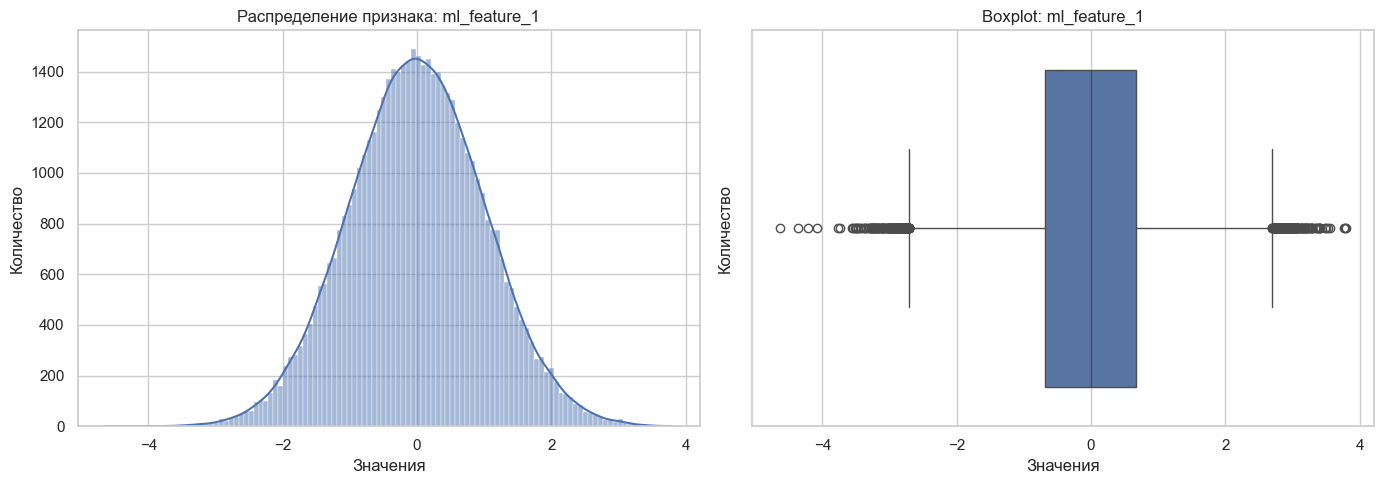

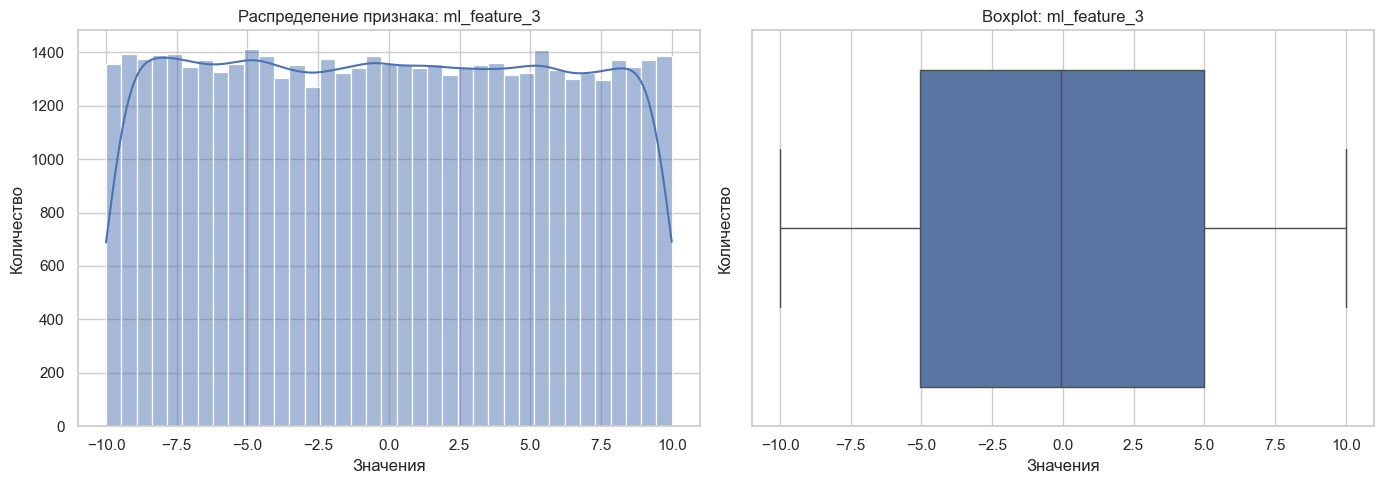

In [20]:
for col in num_cols[:2]:
    graphics_numerical(col)

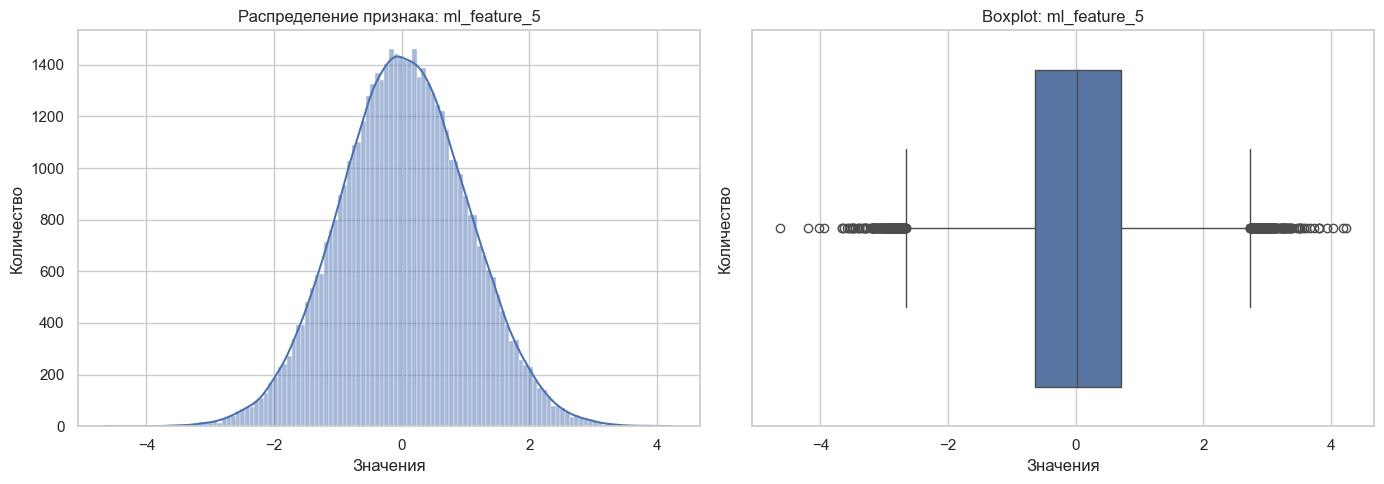

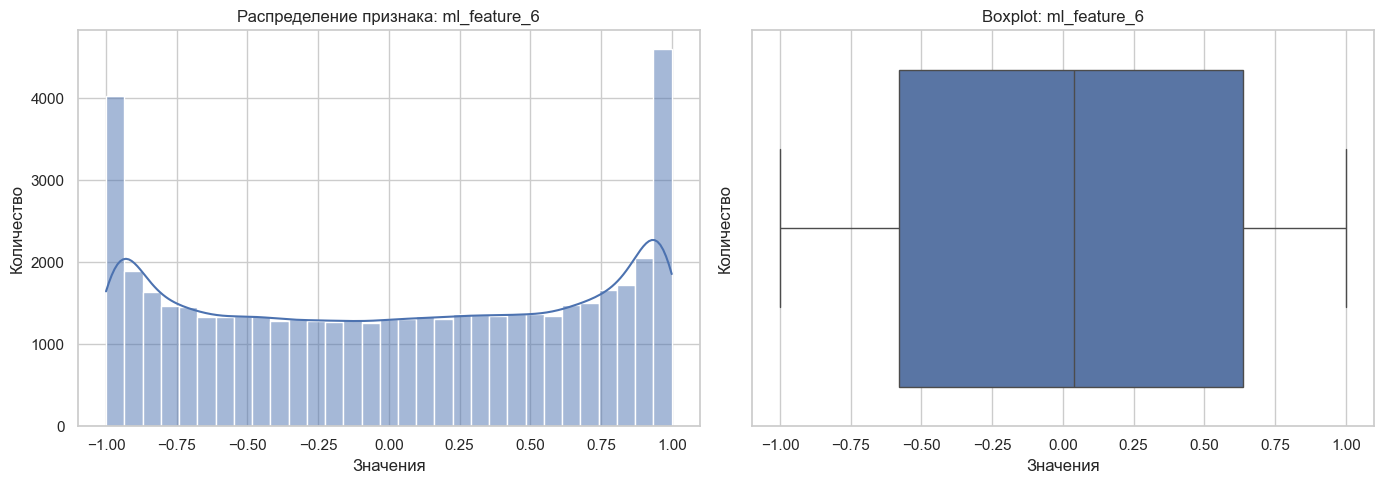

In [21]:
for col in num_cols[2:4]:
    graphics_numerical(col)

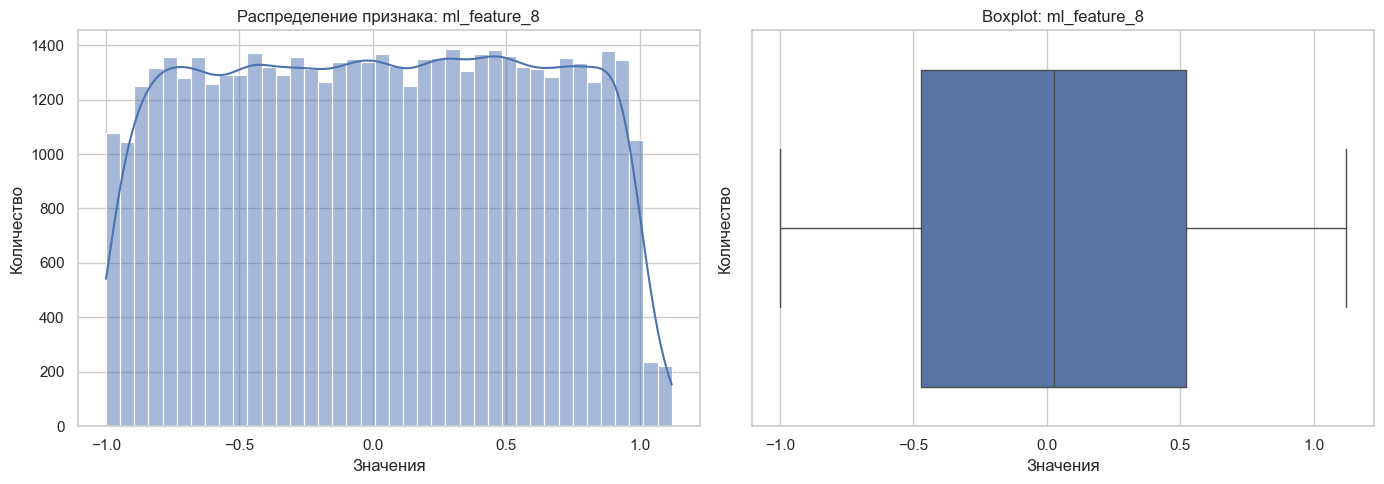

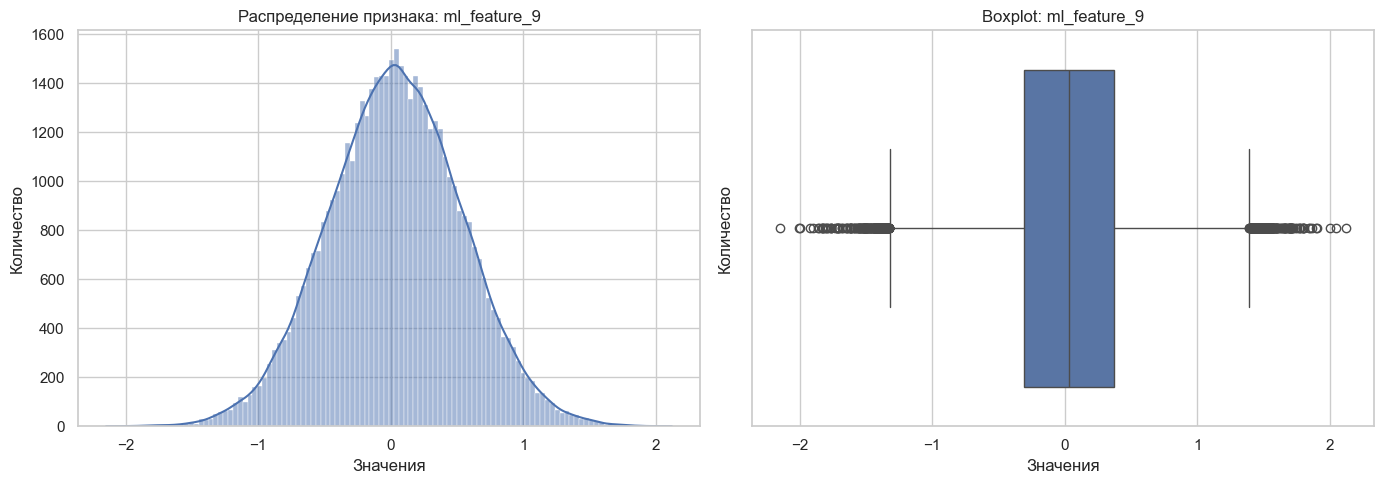

In [22]:
for col in num_cols[4:6]:
    graphics_numerical(col)

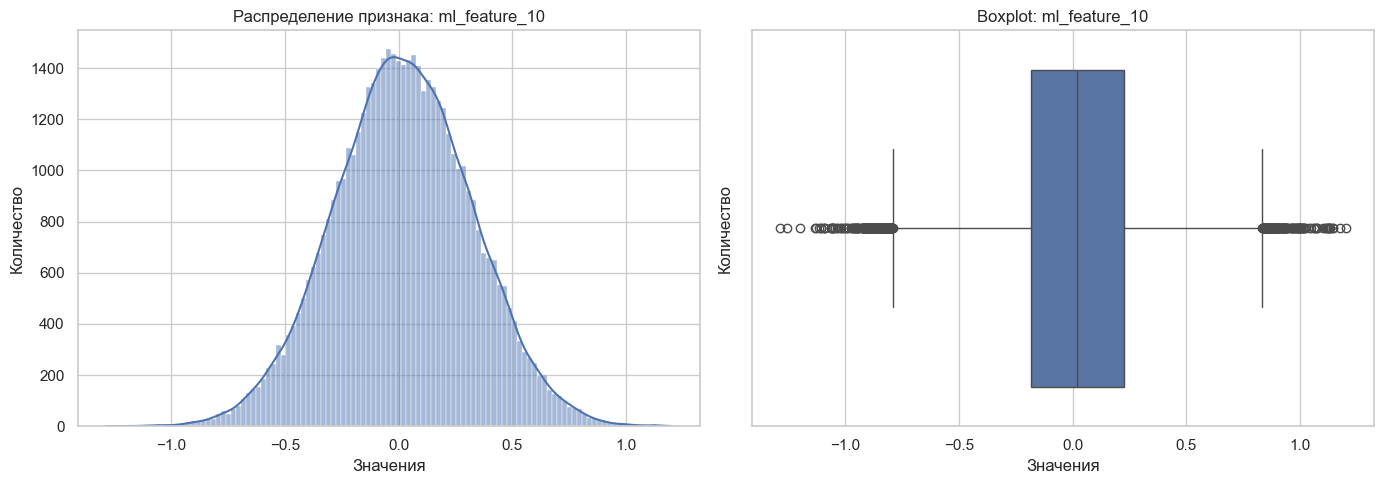

In [23]:
for col in num_cols[6:]:
    graphics_numerical(col)

По графикам распределений и boxplot видно, что числовые ML-признаки не содержат грубых аномалий. Формально IQR-метод выделяет небольшую долю хвостовых значений у ml_feature_1, ml_feature_5, ml_feature_9 и ml_feature_10, но их доля меньше 1% по каждому признаку. Эти значения выглядят как естественные хвосты распределений, а не как ошибки данных.

Признак ml_feature_3 имеет широкий диапазон значений, но IQR-метод не считает его значения выбросами, так как его межквартильный размах также велик. Поэтому широкий разброс ml_feature_3 является особенностью распределения, а не проблемой качества данных.

### Формирование временных признаков, анализ распределения

In [24]:
def values_viewing(column):
    print('=' * 100)
    print(f'Распределение {column}, количество и доля')
    share_target = df[column].value_counts(normalize=True)
    absolut_target = df[column].value_counts(dropna=False)
    target_values = pd.concat([absolut_target, share_target], axis=1)
    target_values.columns = ['Количество', 'Доля']
    display(target_values.sort_values(by=column, ascending=False))

In [25]:
df["dayofweek"] = df["hour"].dt.dayofweek
df['dayofweek'] = df['dayofweek'].replace({0: 'Понедельник',
                                           1: 'Вторник',
                                           2: 'Среда',
                                           3: 'Четверг',
                                           4: 'Пятница',
                                           5: 'Суббота',
                                           6: 'Воскресенье'})
df["hour_of_day"] = df["hour"].dt.hour
df["month"] = df["hour"].dt.month
df['hour_sin'] = np.sin(2 * np.pi * df['hour_of_day'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour_of_day'] / 24)
time_col = ['hour', 'dayofweek', 'hour_of_day', 'month', 'hour_sin', 'hour_cos']

Для часа суток будет использовано циклическое кодирование через `sin` и `cos`, так как время имеет циклическую природу: 23:00 и 00:00 близки друг к другу, хотя при обычном числовом кодировании находятся далеко.

In [26]:
new_time_cols = ['month', 'dayofweek', 'hour_of_day']
for col in new_time_cols:
    values_viewing(col)

Распределение month, количество и доля


,Количество,Доля
month,,
10,50000,1.0


Распределение dayofweek, количество и доля


,Количество,Доля
dayofweek,,
Четверг,10056,0.20112
Суббота,4179,0.08358
Среда,11256,0.22512
Пятница,4077,0.08154
Понедельник,3979,0.07958
Вторник,11743,0.23486
Воскресенье,4710,0.09420


Распределение hour_of_day, количество и доля


,Количество,Доля
hour_of_day,,
23,957,0.01914
22,1082,0.02164
21,1235,0.02470
20,1366,0.02732
19,1598,0.03196
18,2168,0.04336
17,2488,0.04976
16,2520,0.05040
15,2536,0.05072


По первичным таблицам распределения видно, что данные агрегированны за 1 месяц, поэтому признак `month` необходимо исключить из модели вместе с старым признаком `hour`

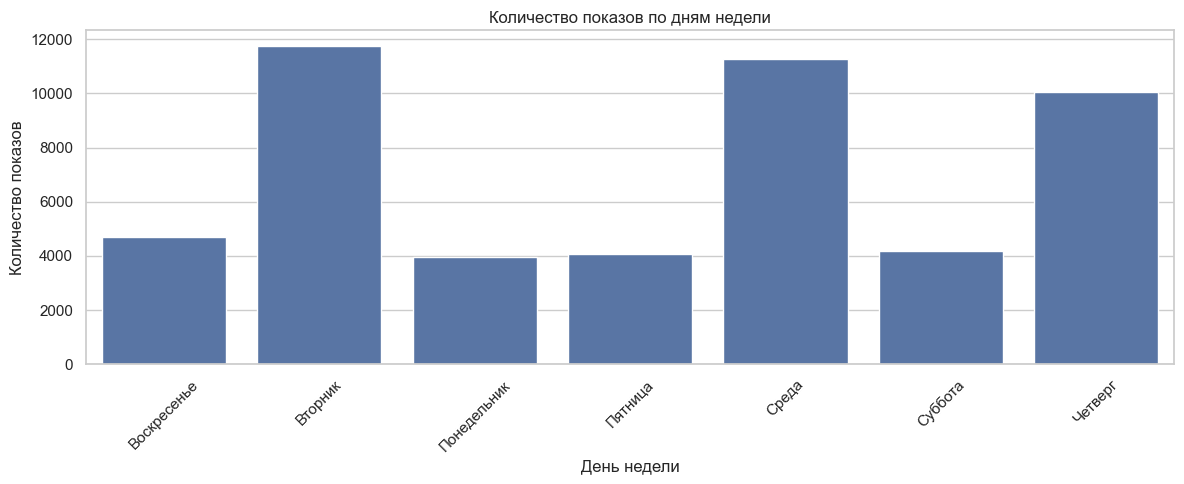

In [27]:
shows_by_date = df.groupby("dayofweek").size()

plt.figure(figsize=(12, 5))
sns.barplot(x=shows_by_date.index, y=shows_by_date.values)

plt.title("Количество показов по дням недели")
plt.xlabel("День недели")
plt.ylabel("Количество показов")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

По графику видно, что количество показов распределено по дням недели неравномерно. Наибольшее число показов приходится на вторник, среду и четверг, а меньшее количество наблюдается в понедельник, пятницу, субботу и воскресенье.

Такое распределение может быть связано с особенностями периода сбора данных, рекламного трафика или настройки кампаний. При этом явно сказать, что показы связаны с выходными/предвыходными днями без дополнительного аналитического блока в достаточной мере сказать трудно.

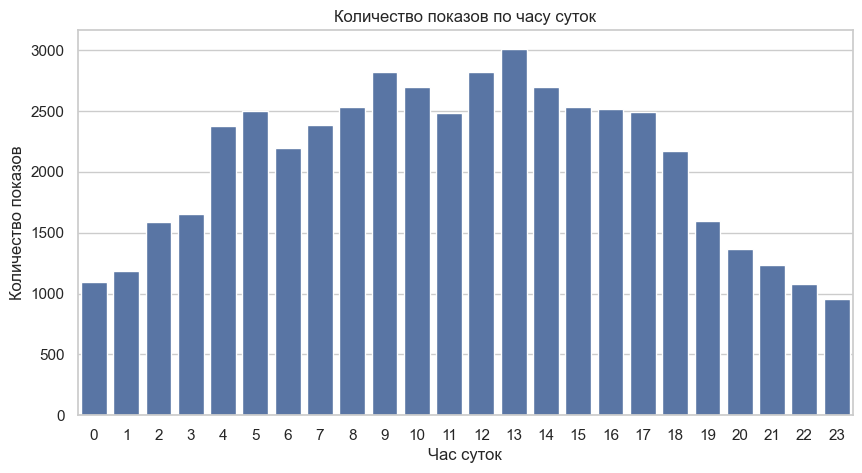

In [28]:
shows_by_hour = df["hour_of_day"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.barplot(x=shows_by_hour.index, y=shows_by_hour.values)

plt.title("Количество показов по часу суток")
plt.xlabel("Час суток")
plt.ylabel("Количество показов")
plt.show()

показы распределены по часам суток неравномерно. Минимальная активность наблюдается ночью и поздним вечером, а максимум приходится примерно на дневные часы, особенно около 13:00. Это говорит о выраженной суточной сезонности пользовательского поведения. Поэтому признак “час показа” является важным для качества модели: он может помочь учитывать разные паттерны активности пользователей в течение дня.

### Распределение числовых категориальных признаков

Признак: C1


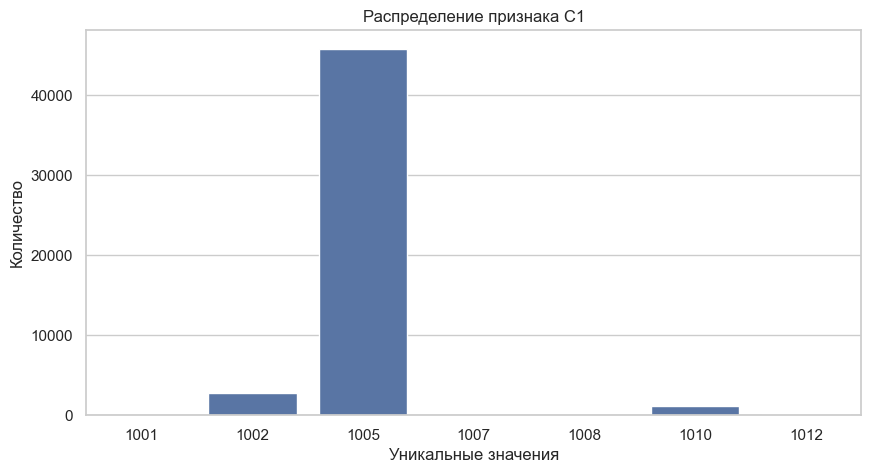

Распределение C1, количество и доля


,Количество,Доля
C1,,
1005,45835,0.91670
1002,2790,0.05580
1010,1179,0.02358
1012,135,0.00270
1007,38,0.00076
1001,16,0.00032
1008,7,0.00014


Признак: C15


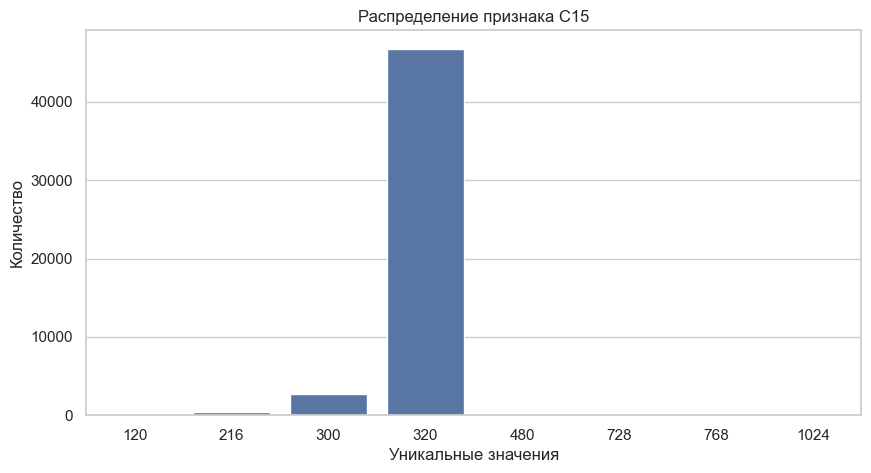

Распределение C15, количество и доля


,Количество,Доля
C15,,
320,46787,0.93574
300,2758,0.05516
216,367,0.00734
728,78,0.00156
1024,5,0.00010
768,3,0.00006
480,1,0.00002
120,1,0.00002


In [29]:
for col in [col for col in num_cat if col in onehot_cols][0:2]:
    graphics_numerical_cat(col)

Признак: C16


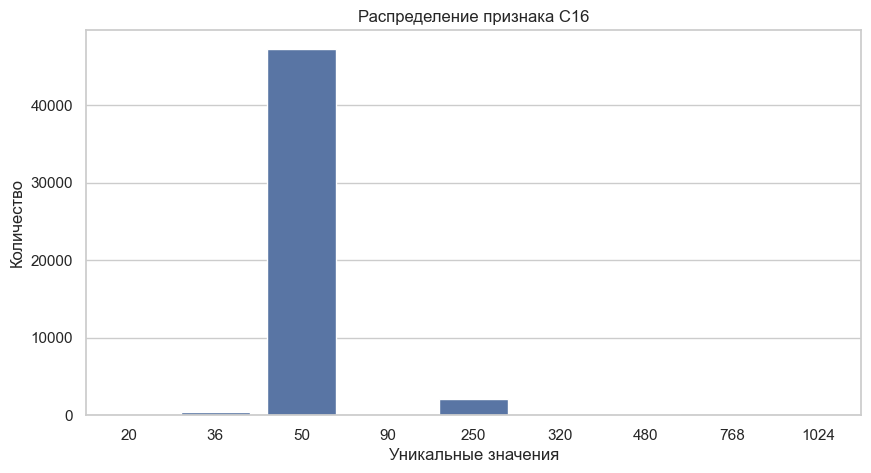

Распределение C16, количество и доля


,Количество,Доля
C16,,
50,47287,0.94574
250,2135,0.04270
36,367,0.00734
480,123,0.00246
90,78,0.00156
768,5,0.00010
1024,3,0.00006
320,1,0.00002
20,1,0.00002


Признак: C18


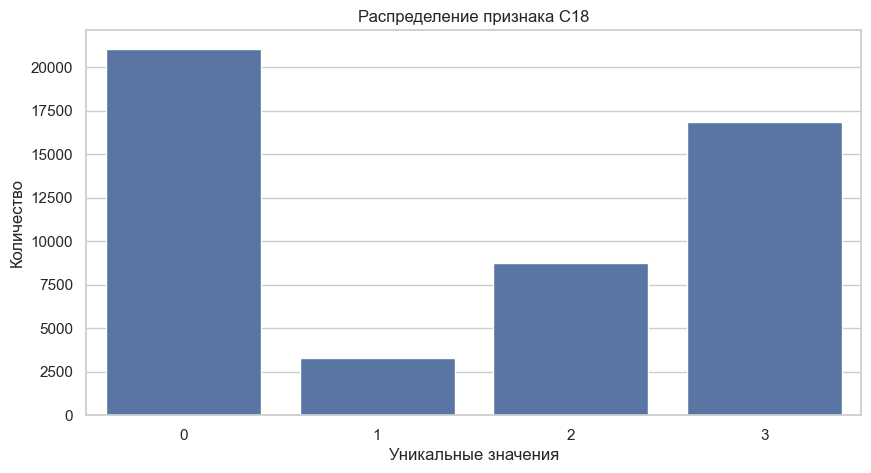

Распределение C18, количество и доля


,Количество,Доля
C18,,
0,21074,0.42148
3,16855,0.33710
2,8769,0.17538
1,3302,0.06604


In [30]:
for col in [col for col in num_cat if col in onehot_cols][2:4]:
    graphics_numerical_cat(col)

Признак: banner_pos


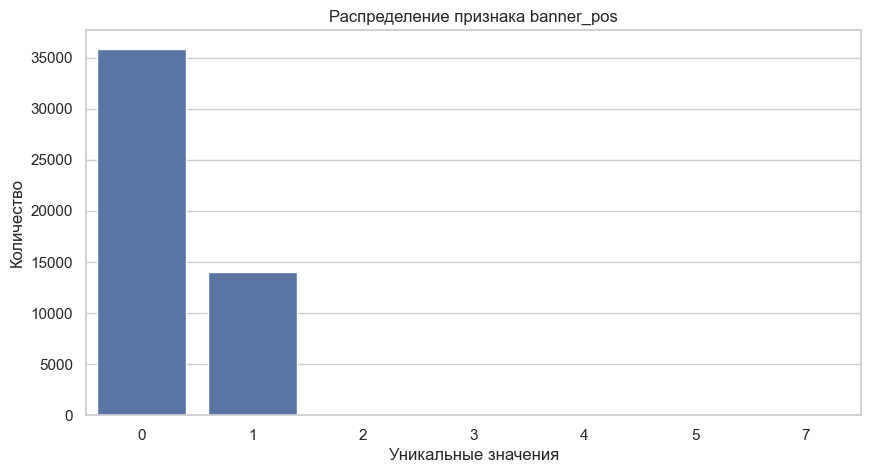

Распределение banner_pos, количество и доля


,Количество,Доля
banner_pos,,
0,35883,0.71766
1,14019,0.28038
7,61,0.00122
2,13,0.00026
4,11,0.00022
5,7,0.00014
3,6,0.00012


Признак: device_conn_type


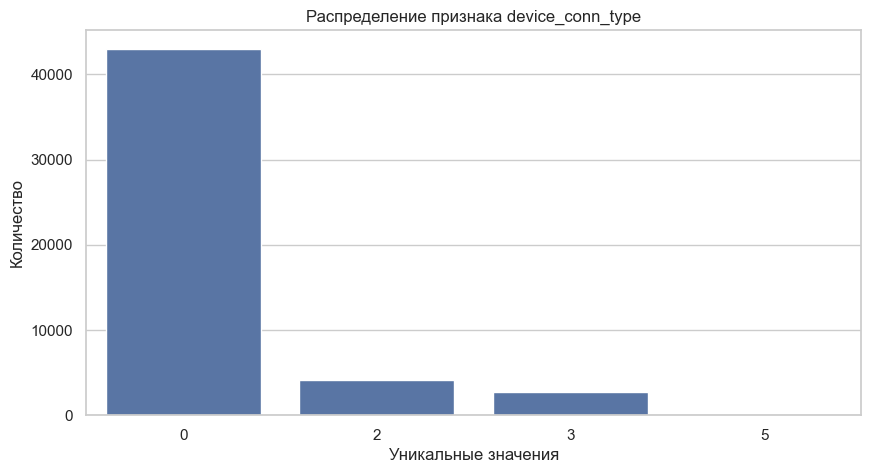

Распределение device_conn_type, количество и доля


,Количество,Доля
device_conn_type,,
0,43021,0.86042
2,4163,0.08326
3,2774,0.05548
5,42,0.00084


In [31]:
for col in [col for col in num_cat if col in onehot_cols][4:6]:
    graphics_numerical_cat(col)

Признак: device_type


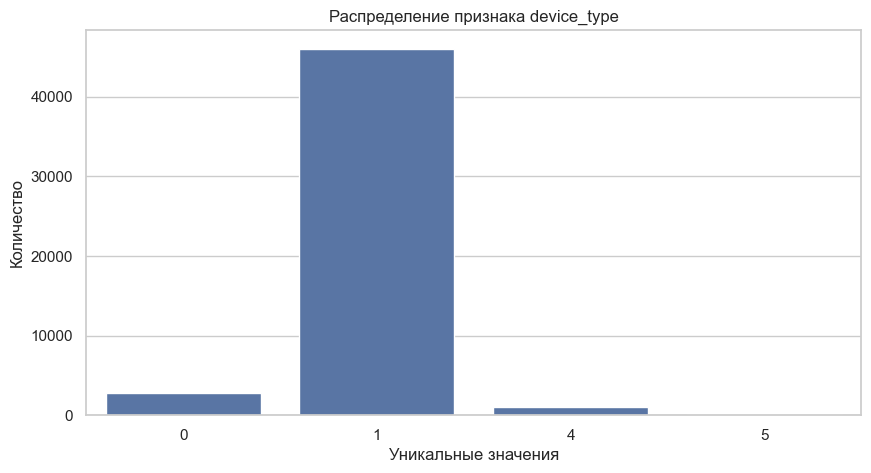

Распределение device_type, количество и доля


,Количество,Доля
device_type,,
1,46031,0.92062
0,2790,0.05580
4,1020,0.02040
5,159,0.00318


Признак: ml_feature_4


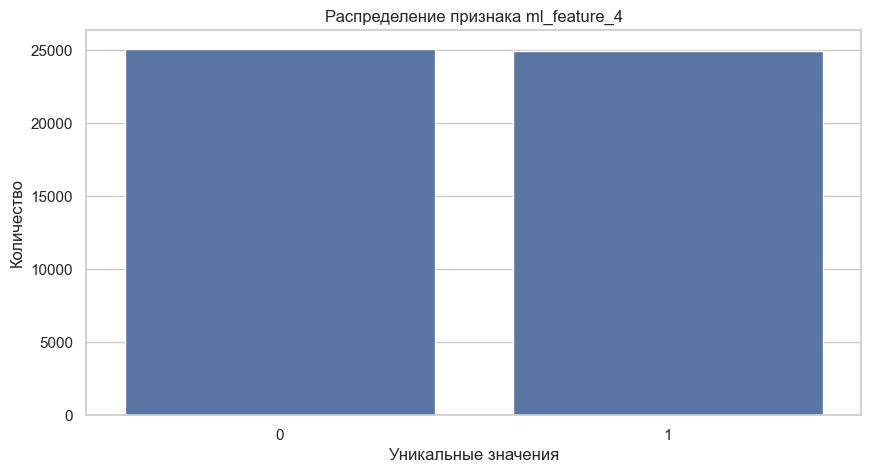

Распределение ml_feature_4, количество и доля


,Количество,Доля
ml_feature_4,,
0,25098,0.50196
1,24902,0.49804


In [32]:
for col in [col for col in num_cat if col in onehot_cols][6:]:
    graphics_numerical_cat(col)

Признаки `C1` `device_type` `c15` `c16` имеют низкую вариативность, поэтому потенциально их разграничение целевой переменной может быть ограниченным.  Решение об удалении стоит принимать на этапе отбора признаков фильтрационным методом.

### Распределение целевой переменной

Признак: click


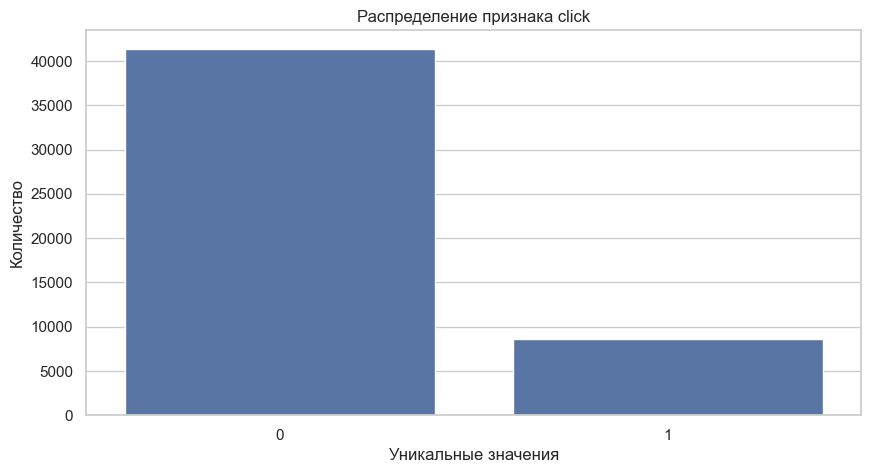

Распределение click, количество и доля


,Количество,Доля
click,,
0,41397,0.82794
1,8603,0.17206


In [33]:
graphics_numerical_cat(target_col)

Целевая переменная распределена неравномерно, ярковыраженный дисбаланс классов. Положительный класс (клики) встречается всего в 17 процентах датасета.

Основной метрикой будет `PR-AUC`, потому что она лучше подходит для задачи с редким положительным классом. В этой задаче важно не просто отличать классы в среднем, а находить клики среди большого числа отсутствия взаимодействий.

Для вероятностных прогнозов будут использоваться:

- `Log Loss`;
- `Brier Score`.

`Log Loss` сильнее штрафует уверенные ошибки, что важно для финансовой задачи.
`Brier Score` удобен для общей оценки качества вероятностей и калибровки.

Дополнительно я посмотрю на калибровочные кривые. Это нужно, потому что одна численная метрика может скрывать проблему: модель может быть хорошо откалибрована в среднем, но сильно ошибаться в отдельных диапазонах вероятностей.

### Уникальные значения категориальных признаков

In [34]:
for col in cat_cols:
    print('=' * 100)
    display(df[col].value_counts().head(8))
    print('=' * 100)

app_category
07d7df22    32388
0f2161f8    11843
cef3e649     2123
8ded1f7a     1793
f95efa07     1375
d1327cf5      163
dc97ec06       82
09481d60       78
Name: count, dtype: int64

app_domain
7801e8d9    33763
2347f47a     6473
ae637522     2341
5c5a694b     1368
82e27996      904
d9b5648e      875
0e8616ad      840
b9528b13      793
Name: count, dtype: int64

app_id
ecad2386    31989
92f5800b     1954
e2fcccd2     1368
febd1138      904
9c13b419      876
7358e05e      755
a5184c22      627
d36838b1      573
Name: count, dtype: int64

device_id
a99f214a    41213
c357dbff       27
0f7c61dc       26
936e92fb       16
afeffc18       11
d857ffbb        6
03559b29        5
02da5312        5
Name: count, dtype: int64

device_model
8a4875bd    3007
d787e91b    1734
1f0bc64f    1711
76dc4769     963
be6db1d7     930
7abbbd5c     854
a0f5f879     809
4ea23a13     785
Name: count, dtype: int64

ml_feature_2
E    10112
D    10057
C    10005
B     9958
A     9868
Name: count, dtype: int64

ml_feature_7
Y    17081
Z    16661
X    16258
Name: count, dtype: int64

site_category
50e219e0    20457
f028772b    15777
28905ebd     9061
3e814130     3729
f66779e6      310
75fa27f6      197
335d28a8      166
76b2941d      126
Name: count, dtype: int64

site_domain
c4e18dd6    18645
f3845767     7968
7e091613     4088
7687a86e     1544
98572c79     1303
16a36ef3     1095
58a89a43      943
9d54950b      481
Name: count, dtype: int64

site_id
85f751fd    18011
1fbe01fe     7968
e151e245     3234
d9750ee7     1262
5b08c53b     1120
5b4d2eda      982
856e6d3f      943
a7853007      577
Name: count, dtype: int64

В ходе анализа распределений и уникальных значений явные и неявные пропуски в датасете не обнаружены. Дополнительно были проверены возможные технические заглушки и аномальные значения, которые могли бы обозначать пропуски.
предварительно видно мультиколлеарные признаки: `app_domain`, `app_category`, но принятие решения по удалению будет проводиться после анализа коррелляций

In [35]:
def split_by_variance(df, cols, threshold=0.0):
    selector = VarianceThreshold(threshold=threshold)
    selector.fit(df[cols])
    selected_cols = df[cols].columns[selector.get_support()].tolist()
    removed_cols = df[cols].columns[~selector.get_support()].tolist()
    variances = dict(zip(cols, selector.variances_))
    print(f'Порог дисперсии: {threshold}')
    print(f'В оставленных признаках: {len(selected_cols)}')
    print(f'В удаленных признаках: {len(removed_cols)}')
    for col in removed_cols:
        print(
            f'Признак: {col}, '
            f'variance: {variances[col]:.6f}, '
            f'уникальных значений: {df[col].nunique(dropna=False)}'
        )

    return selected_cols, removed_cols

In [36]:
def check_cols(rem_cols, data):
    for col in rem_cols:
        print(
            f"Признак для удаления: {col}, "
            f"количество уникальных значений: {data[col].nunique(dropna=False)}, "
            f"уникальные значения: {data[col].unique()[:3]}"
        )


In [37]:
def selected_cols(cols, to_del_cols):
    return [
        col for col in cols
        if col not in to_del_cols
    ]

In [38]:
X = df.drop(columns=target_col)
y = df[target_col]

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=rs,
    stratify=y
)

X_calib, X_test, y_calib, y_test = train_test_split(
    X_tmp,
    y_tmp,
    test_size=0.5,
    random_state=rs,
    stratify=y_tmp
)

selection_df = pd.concat([X_train, y_train], axis=1)

##Константа в числовых
num_cols, removed_num_cols = split_by_variance(selection_df, num_cols)
num_cat, removed_num_cat_cols = split_by_variance(selection_df, num_cat)

##Константа в категориальных
removed_cat_cols = [
    col for col in cat_cols
    if selection_df[col].nunique(dropna=False) == 1
]

##Неинфмормативные временные пртзнаки
time_removed_cols = ['hour', 'month']

removed_cols = time_removed_cols + removed_cat_cols + like_id_col + removed_num_cols + removed_num_cat_cols
print('=' * 100)
print(f'Признаки для удаления: {removed_cols}')
print('=' * 100)


Порог дисперсии: 0.0
В оставленных признаках: 7
В удаленных признаках: 0
Порог дисперсии: 0.0
В оставленных признаках: 13
В удаленных признаках: 0
Признаки для удаления: ['hour', 'month', 'id', 'device_ip']


In [39]:
variance_cat = {}
for col in onehot_cols + target_encoding_cols:
    top_share = selection_df[col].value_counts(normalize=True, dropna=False).iloc[0]

    if top_share > 0.95:
        variance_cat[col] = top_share
display(variance_cat)

{}

In [40]:
total_size = len(y)

print('Размеры:')
print(f'Train: {X_train.shape}, {y_train.shape[0]}, доля: {len(y_train) / total_size:.2%}')
print(f'Calibration: {X_calib.shape}, {y_calib.shape[0]}, доля: {len(y_calib) / total_size:.2%}')
print(f'Test: {X_test.shape}, {y_test.shape[0]}, доля: {len(y_test) / total_size:.2%}')

Размеры:
Train: (35000, 38), 35000, доля: 70.00%
Calibration: (7500, 38), 7500, доля: 15.00%
Test: (7500, 38), 7500, доля: 15.00%


In [41]:
check_cols(removed_cols, selection_df)

Признак для удаления: hour, количество уникальных значений: 240, уникальные значения: <DatetimeArray>
['2014-10-25 14:00:00', '2014-10-23 01:00:00', '2014-10-23 21:00:00']
Length: 3, dtype: datetime64[us]
Признак для удаления: month, количество уникальных значений: 1, уникальные значения: [10]
Признак для удаления: id, количество уникальных значений: 35000, уникальные значения: [2.60379148e+18 3.08612042e+18 8.49278455e+18]
Признак для удаления: device_ip, количество уникальных значений: 29718, уникальные значения: <StringArray>
['88bfc65c', '4e7d29ce', '6b9769f2']
Length: 3, dtype: str


In [42]:
cat_cols = selected_cols(cat_cols, removed_cat_cols)
time_cols = selected_cols(time_col, time_removed_cols)

all_selected = num_cols + num_cat + cat_cols + time_cols + [target_col]

diff_cols = df.columns.difference(all_selected + removed_cols).tolist()
print(f'Не распределенные признаки: {diff_cols}')
print('=' * 100)
print("Оставленные категориальные признаки:", cat_cols)
print('')
print("категориальные признаки на удаление:", removed_cat_cols)
print('=' * 100)
print("Оставленные числовые признаки:", num_cols)
print('')
print("числовые признаки на удаление:", removed_num_cols)
print('=' * 100)
print("Оставленные числовые категориальные", num_cat)
print('=' * 100)
print("Оставленные временные", time_cols)
print("Удалённые признаки всего:", removed_cols)

Не распределенные признаки: []
Оставленные категориальные признаки: ['app_category', 'app_domain', 'app_id', 'device_id', 'device_model', 'ml_feature_2', 'ml_feature_7', 'site_category', 'site_domain', 'site_id']

категориальные признаки на удаление: []
Оставленные числовые признаки: ['ml_feature_1', 'ml_feature_3', 'ml_feature_5', 'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10']

числовые признаки на удаление: []
Оставленные числовые категориальные ['C1', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'banner_pos', 'device_conn_type', 'device_type', 'ml_feature_4']
Оставленные временные ['dayofweek', 'hour_of_day', 'hour_sin', 'hour_cos']
Удалённые признаки всего: ['hour', 'month', 'id', 'device_ip']


Будет удален константный для текущего периода признак `month`, исходный временной признак `hour`, а также явно неинформативные ID-подобные признаки `id` и `device_ip` с очень высокой кардинальностью. Остальные удаления требуют отдельного анализа корреляций, мультиколлинеарности и связи с целевой переменной.


Для кодирования категориальных признаков используется единый порог кардинальности `threshold_onehot = 22`: признаки с числом уникальных значений не выше порога кодируются через `OneHotEncoder`, более высококардинальные признаки - через `TargetEncoder` внутри пайплайна.

## Коррелляционный анализ

In [43]:
col_for_matrix = []

for col in all_selected:
    if col in selection_df.columns and selection_df[col].nunique() < 150:
        col_for_matrix.append(col)

print(col_for_matrix)

['C1', 'C15', 'C16', 'C18', 'C19', 'C20', 'C21', 'banner_pos', 'device_conn_type', 'device_type', 'ml_feature_4', 'app_category', 'app_domain', 'ml_feature_2', 'ml_feature_7', 'site_category', 'dayofweek', 'hour_of_day', 'hour_sin', 'hour_cos', 'click']


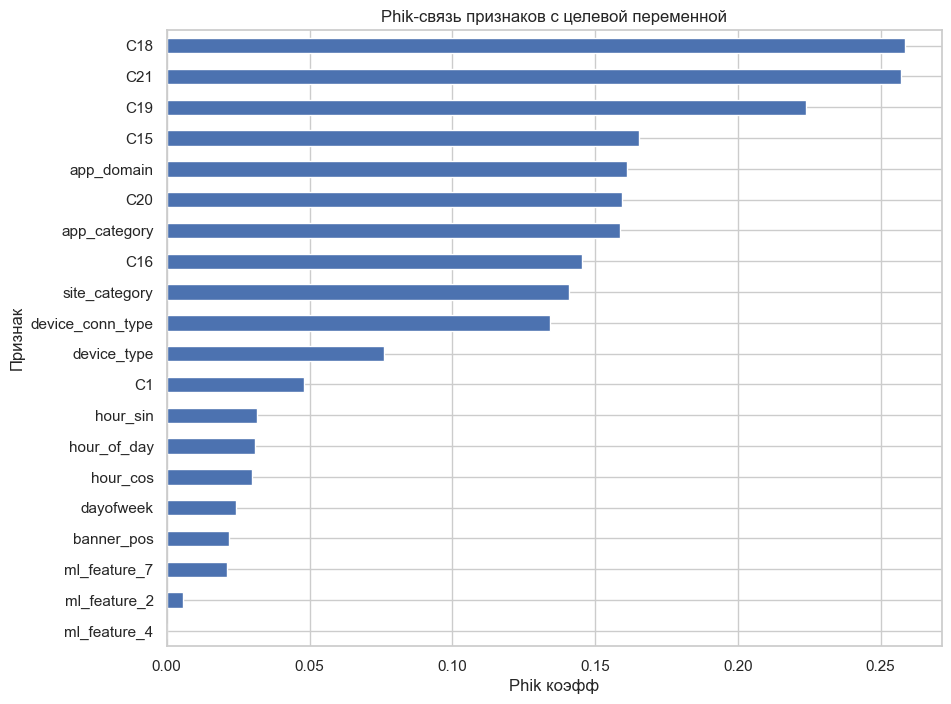

C18                 0.258469
C21                 0.257164
C19                 0.223945
C15                 0.165541
app_domain          0.161132
C20                 0.159323
app_category        0.158611
C16                 0.145550
site_category       0.140707
device_conn_type    0.134272
device_type         0.076193
C1                  0.048201
hour_sin            0.031533
hour_of_day         0.031003
hour_cos            0.029721
dayofweek           0.024354
banner_pos          0.021696
ml_feature_7        0.020972
ml_feature_2        0.005610
ml_feature_4        0.000000
Name: click, dtype: float64

In [44]:
interval_cols_for_phik = [
    col for col in num_cols
    if col in col_for_matrix
]
phik_corr = selection_df[col_for_matrix].phik_matrix(interval_cols=interval_cols_for_phik)
target_phik = (
    phik_corr['click']
    .drop('click')
    .sort_values(ascending=False)
)

target_phik.sort_values().plot(kind='barh', figsize=(10, 8))
plt.title('Phik-связь признаков с целевой переменной')
plt.xlabel('Phik коэфф')
plt.ylabel('Признак')
plt.show()
display(target_phik)


По результатам PhiK-анализа наибольшую связь с целевой переменной показывают C18, C21, C15, app_domain, app_category и site_category. Признаки ml_feature_2 и ml_feature_4 имеют близкую к нулю индивидуальную связь с таргетом, поэтому могут быть рассмотрены как кандидаты на удаление.

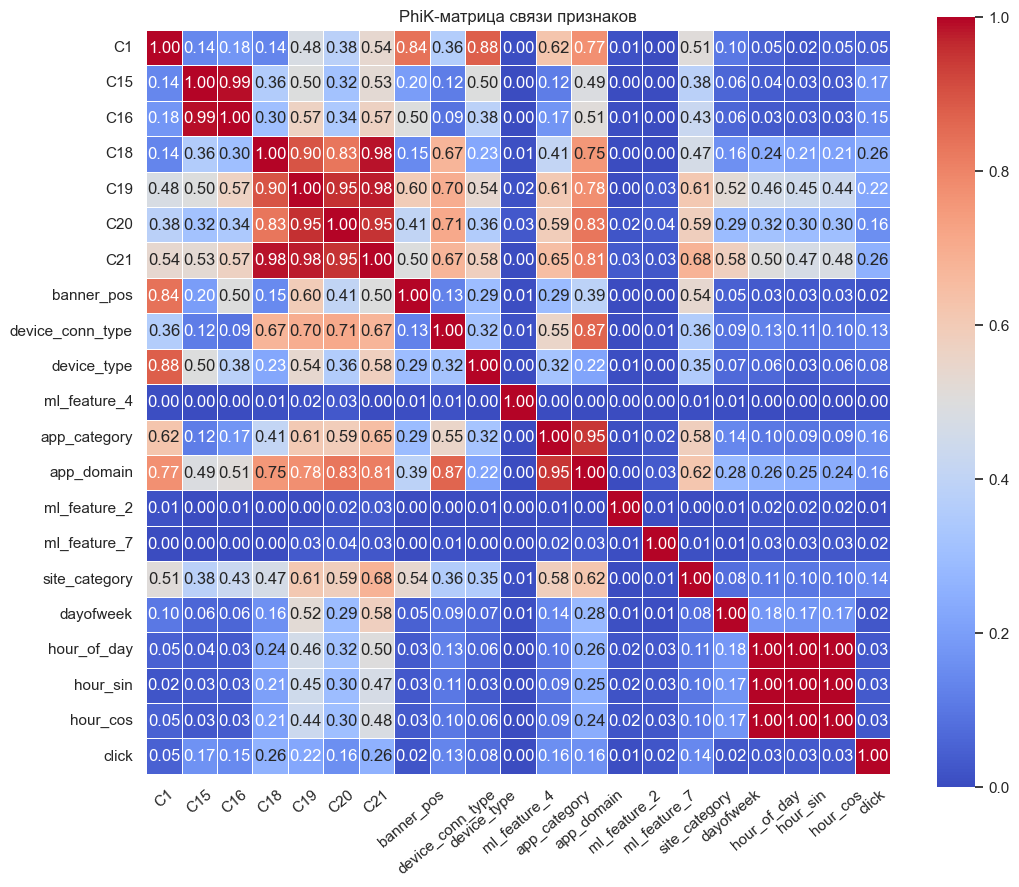

In [45]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    phik_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=0,
    vmax=1,
    square=True,
    linewidths=0.5
)
plt.title('PhiK-матрица связи признаков')
plt.xticks(rotation=40)
plt.show()


PhiK-матрица показывает, что часть признаков сильно связана между собой. Наиболее выраженные связи наблюдаются между C15 и C16 - 0.99, app_category и app_domain - 0.94. а также между C18, C21 и рядом признаков, связанных с приложением и сайтом. Это указывает на возможную избыточность части признаков: некоторые из них могут описывать близкие аспекты объекта или быть производными друг от друга. Таким образом, появилось еще 2 кандидата на удаление - `C15` и `app_domain`

Таким образом на данном этапе удаляются 5 признаков: `ml_feature_2`, `ml_feature_4`, `C15`, `app_domain` и `hour_of_day`. Признак `hour_of_day` из-за замены циклическими признаками  `hour_sin` и `hour_cos`.


In [46]:
drop_col = ['ml_feature_2', 'ml_feature_4', 'C15', 'app_domain', 'hour_of_day']
removed_cols.extend(drop_col)

## Фильтрационные методы отбора признаков

In [47]:
df[onehot_cols].describe()

,C1,C15,C16,C18,banner_pos,device_conn_type,device_type,ml_feature_4
count,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1004.970060,318.86640,59.692480,1.428100,0.291380,0.337160,1.018120,0.498040
std,1.110202,20.56153,46.720842,1.327413,0.514201,0.860057,0.538477,0.500001
min,1001.000000,120.00000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1005.000000,320.00000,50.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,1005.000000,320.00000,50.000000,2.000000,0.000000,0.000000,1.000000,0.000000
75%,1005.000000,320.00000,50.000000,3.000000,1.000000,0.000000,1.000000,1.000000
max,1012.000000,1024.00000,1024.000000,3.000000,7.000000,5.000000,5.000000,1.000000


In [48]:
cat_results = []

for col in onehot_cols:
    table = pd.crosstab(selection_df[col], selection_df[target_col])
    chi2_stat, p_value, dof, expected = chi2_contingency(table)
    cramers_v = association(table, method="cramer")
    cat_results.append({
        "feature": col,
        "chi2": chi2_stat,
        "p_value": p_value,
        "cramers_v": cramers_v,
        "n_categories": selection_df[col].nunique()
    })

cat_chi2_result = (
    pd.DataFrame(cat_results)
    .sort_values("cramers_v", ascending=False)
)

display(cat_chi2_result)


,feature,chi2,p_value,cramers_v,n_categories
7,C18,1036.658758,2.007184e-224,0.172101,4
6,C16,747.653885,3.911760e-156,0.146156,9
3,site_category,573.584180,9.099355e-112,0.128016,17
0,app_category,563.271406,8.400618e-109,0.126860,18
5,C15,547.146725,5.803350e-114,0.125031,8
9,device_conn_type,280.026286,2.090002e-60,0.089447,4
4,C1,99.120451,3.828471e-19,0.053217,7
10,device_type,92.069113,7.872013e-20,0.051289,4
2,ml_feature_7,44.446340,2.231516e-10,0.035636,3
8,banner_pos,24.866982,3.613693e-04,0.026655,7


По `Cramer's` и `mutual_info_classif` признак `banner_pos` показал самую слабую связь с таргетом  хи квадрат `35.25`, cramers `0.026` и 0.0003 mutual
признак будет удален как слабый

In [49]:
selection_df['banner_pos'].value_counts()

banner_pos
0    25082
1     9843
7       44
2       13
4        8
5        5
3        5
Name: count, dtype: int64

In [50]:
removed_cols.append('banner_pos')

In [51]:
def mutual_info(cols, discrete):
    mi_scores = mutual_info_classif(
        X_train[cols],
        y_train,
        discrete_features=discrete,
        random_state=rs
    )

    mi_scores = (
        pd.Series(mi_scores, index=cols)
        .sort_values(ascending=False)
    )

    display(mi_scores)

    return mi_scores

In [52]:
mutual_info(num_cols, discrete=False)

ml_feature_8     0.027379
ml_feature_9     0.013175
ml_feature_10    0.009877
ml_feature_6     0.004740
ml_feature_3     0.002185
ml_feature_1     0.000000
ml_feature_5     0.000000
dtype: float64

ml_feature_8     0.027379
ml_feature_9     0.013175
ml_feature_10    0.009877
ml_feature_6     0.004740
ml_feature_3     0.002185
ml_feature_1     0.000000
ml_feature_5     0.000000
dtype: float64

In [53]:
mutual_info(onehot_cols, discrete=True)

C18                 0.015588
app_category        0.008722
C16                 0.008464
site_category       0.008280
C15                 0.006488
device_conn_type    0.005207
C1                  0.001519
device_type         0.001365
ml_feature_7        0.000640
banner_pos          0.000360
ml_feature_2        0.000080
ml_feature_4        0.000009
dtype: float64

C18                 0.015588
app_category        0.008722
C16                 0.008464
site_category       0.008280
C15                 0.006488
device_conn_type    0.005207
C1                  0.001519
device_type         0.001365
ml_feature_7        0.000640
banner_pos          0.000360
ml_feature_2        0.000080
ml_feature_4        0.000009
dtype: float64

По результатам Mutual Information среди непрерывных числовых признаков нулевую связь с целевой переменной показали `ml_feature_1` и `ml_feature_5`, поэтому они добавлены в список признаков к удалению.

Среди низкокардинальных категориальных признаков самые слабые значения MI получили `ml_feature_7` и `dayofweek`. Эти признаки также удаляются как слабые по индивидуальной связи с таргетом.

Остальные признаки сохраняются, так как показывают более заметную связь с целевой переменной или будут дополнительно оцениваться на этапе моделирования.


In [54]:
drop_cols = ['ml_feature_1', 'ml_feature_5', 'ml_feature_7', 'dayofweek']
removed_cols.extend(drop_cols)

## Методы-обертки

In [55]:
print(f'Признаков до удаления: {df.shape[1]}')
print('=' * 100)
df.drop(columns=removed_cols, inplace=True)
X_train.drop(columns=removed_cols, inplace=True)
X_calib.drop(columns=removed_cols, inplace=True)
X_test.drop(columns=removed_cols, inplace=True)

selection_df = pd.concat([X_train, y_train], axis=1)

cat_cols = [col for col in cat_cols if col not in removed_cols]
num_cols = [col for col in num_cols if col not in removed_cols]
num_cat = [col for col in num_cat if col not in removed_cols]
time_cols = [col for col in time_cols if col not in removed_cols]

time_num_cols = [col for col in ['hour_sin', 'hour_cos'] if col in df.columns]
time_cat_cols = [col for col in ['dayofweek'] if col in df.columns]

num_cols_model = num_cols + time_num_cols
categorical_cols = cat_cols + num_cat + time_cat_cols

onehot_cols = [
    col for col in categorical_cols
    if df[col].nunique(dropna=False) <= threshold_onehot
]

target_encoding_cols = [
    col for col in categorical_cols
    if df[col].nunique(dropna=False) > threshold_onehot
]

all_selected = num_cols + num_cat + cat_cols + time_cols + [target_col]

print(f'Оставшиеся признаки: {all_selected}')
print('=' * 100)
print(f'Признаков после удаления: {df.shape[1]}')
print('=' * 100)
print(f'Числовые признаки для масштабирования: {num_cols_model}')
print(f'OneHot признаки: {onehot_cols}')
print(f'TargetEncoding признаки: {target_encoding_cols}')



Признаков до удаления: 39
Оставшиеся признаки: ['ml_feature_3', 'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10', 'C1', 'C14', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'device_conn_type', 'device_type', 'app_category', 'app_id', 'device_id', 'device_model', 'site_category', 'site_domain', 'site_id', 'hour_sin', 'hour_cos', 'click']
Признаков после удаления: 25
Числовые признаки для масштабирования: ['ml_feature_3', 'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10', 'hour_sin', 'hour_cos']
OneHot признаки: ['app_category', 'site_category', 'C1', 'C16', 'C18', 'device_conn_type', 'device_type']
TargetEncoding признаки: ['app_id', 'device_id', 'device_model', 'site_domain', 'site_id', 'C14', 'C17', 'C19', 'C20', 'C21']


In [56]:
check_cols = set(num_cols_model + onehot_cols + target_encoding_cols + [target_col])

print('Нет в df:', check_cols - set(df.columns))
print('Лишние в df:', set(df.columns) - check_cols)

Нет в df: set()
Лишние в df: set()


In [57]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=rs)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols_model),
        ('cat', OneHotEncoder(handle_unknown='ignore', min_frequency=20), onehot_cols),
        ('target', TargetEncoder(target_type='binary', cv=5, random_state=rs), target_encoding_cols),
    ],
    remainder='drop'
)
base_logistic = LogisticRegression(solver='liblinear', random_state=rs, max_iter=1000)

In [58]:
rfecv = RFECV(
    estimator=base_logistic,
    step=1,
    cv=cv,
    scoring="average_precision",
    min_features_to_select=20,
    n_jobs=-1
)

pipe_logistic_rfecv = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('rfecv', rfecv),
])

pipe_logistic_rfecv.fit(X_train, y_train)

feature_names = pipe_logistic_rfecv.named_steps['preprocessor'].get_feature_names_out()

removed_features = feature_names[
    ~pipe_logistic_rfecv.named_steps['rfecv'].support_
]

print('признаки на удаление:')
print(removed_features)


признаки на удаление:
['num__ml_feature_3' 'num__hour_sin' 'cat__app_category_d1327cf5']


По результатам RFECV среди исходных числовых признаков к удалению повторно попал `ml_feature_3`. Этот же признак ранее показывал низкое значение Mutual Information, поэтому он добавляется в итоговый список удаляемых признаков.

`hour_sin` и `hour_cos` также были отмечены RFECV как слабые признаки, но их вклад будет оцениваться отдельно на финальной модели

In [59]:
num_cols_model.remove('ml_feature_3')
df.drop(columns='ml_feature_3', inplace=True)
X_train.drop(columns='ml_feature_3', inplace=True)
X_calib.drop(columns='ml_feature_3', inplace=True)
X_test.drop(columns='ml_feature_3', inplace=True)
selection_df = pd.concat([X_train, y_train], axis=1)

print(f'Итоговые признаки оставленные в датасете: {df.columns}, количество: {len(df)}')


Итоговые признаки оставленные в датасете: Index(['click', 'C1', 'site_id', 'site_domain', 'site_category', 'app_id', 'app_category', 'device_id', 'device_model', 'device_type', 'device_conn_type', 'C14', 'C16', 'C17', 'C18', 'C19', 'C20',
       'C21', 'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10', 'hour_sin', 'hour_cos'],
      dtype='str'), количество: 50000


In [60]:
print(f'Итоговые признаки оставленные в датасете: {df.columns}, количество: {df.shape[1]}')

Итоговые признаки оставленные в датасете: Index(['click', 'C1', 'site_id', 'site_domain', 'site_category', 'app_id', 'app_category', 'device_id', 'device_model', 'device_type', 'device_conn_type', 'C14', 'C16', 'C17', 'C18', 'C19', 'C20',
       'C21', 'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10', 'hour_sin', 'hour_cos'],
      dtype='str'), количество: 24


In [61]:
scores = {}
scoring = {
            'pr_auc': 'average_precision',
            'roc_auc': 'roc_auc',
            'f1': 'f1',
            'recall': 'recall',
            'precision': 'precision'
        }

In [62]:
def evaluate_model(model, model_name):
    cv_result = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    scores[model_name] = {
        'pr_auc_mean': cv_result['test_pr_auc'].mean(),
        'roc_auc_mean': cv_result['test_roc_auc'].mean(),
        'f1_mean': cv_result['test_f1'].mean(),
        'recall_mean': cv_result['test_recall'].mean(),
        'precision_mean': cv_result['test_precision'].mean(),
        'pr_auc_std': cv_result['test_pr_auc'].std()
    }

    scores_df = pd.DataFrame(scores).T.sort_values(by='pr_auc_mean', ascending=False)
    display(scores_df.round(4))

    return cv_result

In [63]:
##замена энкодера, т.к svc на прошлом крос-вале обучался очень долго
preprocessor_2 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols_model),
        ('cat', OneHotEncoder(handle_unknown='ignore', min_frequency=20), onehot_cols),
        ('target', CatTargetEncoder(
            cols=target_encoding_cols,
            smoothing=10,
            min_samples_leaf=20,
            return_df=False), target_encoding_cols),
    ],
    remainder='drop'
)

In [64]:
dummy_model = DummyClassifier(strategy="stratified", random_state=rs)
dummy = evaluate_model(dummy_model, 'dummy')

,pr_auc_mean,roc_auc_mean,f1_mean,recall_mean,precision_mean,pr_auc_std
dummy,0.1726,0.5016,0.1729,0.171,0.1747,0.0015


In [65]:
pipe_logistic = Pipeline(steps=[
    ('preprocessor', preprocessor_2),
    ('model', LogisticRegression(solver='liblinear', random_state=rs, max_iter=1000)),
])
logistic = evaluate_model(pipe_logistic, 'logistic')

,pr_auc_mean,roc_auc_mean,f1_mean,recall_mean,precision_mean,pr_auc_std
logistic,0.4049,0.7523,0.2287,0.1431,0.5695,0.0153
dummy,0.1726,0.5016,0.1729,0.1710,0.1747,0.0015


Логистическая регрессия заметно превосходит DummyClassifier по основной метрике PR-AUC: `0.4049` против `0.1726`. ROC-AUC также существенно выше у логистической регрессии (`0.7523` против `0.5016`), что подтверждает наличие полезного сигнала в признаках.

При этом recall у логистической регрессии остаётся низким (`0.1431`), то есть на стандартном пороге модель находит только часть кликов. Precision при этом достаточно высокая (`0.5695`), поэтому модель реже ошибается среди объектов, которые относит к положительному классу. Дальше важно оценивать не только бинарные предсказания, но и качество вероятностей: Log Loss, Brier Score и калибровку.



In [66]:
#pipe_svc = Pipeline(steps=[
    #('preprocessor', preprocessor_2),
    #('model', SVC(kernel='linear', probability=False, random_state=rs)),
#])

#svc = evaluate_model(pipe_svc, 'svc')

SVC показывает средний результат среди проверенных моделей: `PR-AUC = 0.3486` против `0.4049` у логистической регрессии и `0.1726` у DummyClassifier. Обе обученные модели заметно превосходят baseline, значит в признаках есть полезный сигнал для предсказания клика.

SVC имеет высокую precision, но очень низкие recall и F1, то есть модель почти не предсказывает положительный класс при стандартном пороге.

####### код закомментирован: даже после перехода от более нового target encoder к старой реализации обучение занимает 5 минут, на грид серче около 22 минуты. На практикуме еще дольше. Оптимизировать код пытался, причину выявить не удалось. итоговые метрики SVC: `pr-auc-mean`: 0.3486	`roc-auc-mean`: 0.6774	`f1`: 0.0125	`recall_mean`: 0.0063	`precision_mean`: 0.7560	`pr_auc_std`: 0.0115

In [67]:
def run_grid_search(model, X, y, cv, model_name, param_grid):
    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring=scoring,
        refit='pr_auc',
        cv=cv,
        n_jobs=-1,
        verbose=1
    )
    grid.fit(X, y)
    best_idx = grid.best_index_
    scores[model_name] = {
        'pr_auc_mean': grid.cv_results_['mean_test_pr_auc'][best_idx],
        'roc_auc_mean': grid.cv_results_['mean_test_roc_auc'][best_idx],
        'f1_mean': grid.cv_results_['mean_test_f1'][best_idx],
        'recall_mean': grid.cv_results_['mean_test_recall'][best_idx],
        'precision_mean': grid.cv_results_['mean_test_precision'][best_idx],
        'pr_auc_std': grid.cv_results_['std_test_pr_auc'][best_idx],
        'best_params': grid.best_params_
    }
    scores_df = pd.DataFrame(scores).T
    display(scores_df)
    top_10_results = (
        pd.DataFrame(grid.cv_results_)
        .sort_values(by='mean_test_pr_auc', ascending=False)[
            ['params', 'mean_test_pr_auc', 'std_test_pr_auc', 'rank_test_pr_auc']
        ]
        .head(10)
    )
    display(top_10_results.round(4))

    return grid


In [68]:
param_grid_logistic = {
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'model__class_weight': [None, 'balanced']
}


param_grid_svc = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__class_weight": [None, "balanced"],
}

In [69]:
grid_logistic = run_grid_search(pipe_logistic, X_train, y_train, cv, 'grid_logistic', param_grid_logistic)

best_logistic_params = grid_logistic.best_params_
best_logistic_model = grid_logistic.best_estimator_

print('Лучшие параметры Logistic Regression:')
print(best_logistic_params)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,pr_auc_mean,roc_auc_mean,f1_mean,recall_mean,precision_mean,pr_auc_std,best_params
dummy,0.172583,0.501577,0.172863,0.17104,0.174724,0.001516,NaN
logistic,0.404946,0.752276,0.228715,0.14314,0.569539,0.015312,NaN
grid_logistic,0.418896,0.759146,0.21634,0.13135,0.614822,0.014942,"{'model__C': 0.1, 'model__class_weight': None}"


,params,mean_test_pr_auc,std_test_pr_auc,rank_test_pr_auc
4,"{'model__C': 0.1, 'model__class_weight': None}",0.4189,0.0149,1
5,"{'model__C': 0.1, 'model__class_weight': 'bala...",0.4138,0.0142,2
3,"{'model__C': 0.01, 'model__class_weight': 'bal...",0.4109,0.0146,3
6,"{'model__C': 1, 'model__class_weight': None}",0.4049,0.0153,4
2,"{'model__C': 0.01, 'model__class_weight': None}",0.4021,0.0158,5
7,"{'model__C': 1, 'model__class_weight': 'balanc...",0.3968,0.0142,6
8,"{'model__C': 10, 'model__class_weight': None}",0.3926,0.0154,7
10,"{'model__C': 100, 'model__class_weight': None}",0.3868,0.0153,8
9,"{'model__C': 10, 'model__class_weight': 'balan...",0.3866,0.0144,9
11,"{'model__C': 100, 'model__class_weight': 'bala...",0.3838,0.0146,10


Лучшие параметры Logistic Regression:
{'model__C': 0.1, 'model__class_weight': None}


GridSearchCV для Logistic Regression показал лучший результат при `C=0.1` и `class_weight=None`. Значение `PR-AUC` выросло с `0.4049` у базовой логистической регрессии до `0.4189` после подбора гиперпараметров.

In [70]:
#grid_svc = run_grid_search(pipe_svc, X_train, y_train, cv, 'grid_svc', param_grid_svc)
#best_svc_params = grid_svc.best_params_
#best_svc_model = grid_svc.best_estimator_

#print('Лучшие параметры SVC:')
#print(best_svc_params)

GridSearchCV для SVC с линейным ядром показал лучший результат при C=0.01 и class_weight='balanced'. После подбора гиперпараметров качество SVC заметно выросло: PR-AUC увеличился с 0.3486 до 0.4155, а F1 вырос с 0.0125 до 0.4295. Особенно сильно улучшился recall: с 0.0063 до 0.6687, что важно для задачи с дисбалансом классов, где модель должна находить клики. При этом precision снизился до 0.3164, то есть модель стала чаще относить объекты к положительному классу и платить за высокий recall большим числом ложноположительных срабатываний. По основной метрике PR-AUC SVC почти догнал логистическую регрессию после GridSearchCV (0.4155 против 0.4189)

Лучшие параметры SVC:
{'model__C': 0.01, 'model__class_weight': 'balanced'}

In [71]:
final_metrics = {}

def evaluate_model_final(model, model_name):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba_test = model.predict_proba(X_test)[:, 1]

    final_metrics[model_name] = {
        'pr_auc': average_precision_score(y_test, y_proba_test),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'brier': brier_score_loss(y_test, y_proba_test),
        'log_loss': log_loss(y_test, y_proba_test),
    }

    final_metrics_df = (
        pd.DataFrame(final_metrics)
        .T
        .sort_values(by='pr_auc', ascending=False)
    )

    display(final_metrics_df.round(4))

    return model


In [95]:
final_metrics = {}

def evaluate_model_final(model, model_name):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba_test = model.predict_proba(X_test)[:, 1]
    else:
        y_proba_test = expit(model.decision_function(X_test))

    final_metrics[model_name] = {
        "pr_auc": average_precision_score(y_test, y_proba_test),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "brier": brier_score_loss(y_test, y_proba_test),
        "log_loss": log_loss(y_test, y_proba_test),
    }

    final_metrics_df = (
        pd.DataFrame(final_metrics)
        .T
        .sort_values(by="pr_auc", ascending=False)
    )

    display(final_metrics_df.round(4))

    return model



In [97]:
logistic_final = evaluate_model_final(best_logistic_model, 'logistic_final')
display(pd.DataFrame(scores).T.sort_values(by='pr_auc_mean', ascending=False))

,pr_auc,f1,recall,precision,brier,log_loss
logistic_final,0.4046,0.2058,0.124,0.6038,0.124,0.3997


,pr_auc_mean,roc_auc_mean,f1_mean,recall_mean,precision_mean,pr_auc_std,best_params
grid_logistic,0.418896,0.759146,0.21634,0.13135,0.614822,0.014942,"{'model__C': 0.1, 'model__class_weight': None}"
logistic,0.404946,0.752276,0.228715,0.14314,0.569539,0.015312,NaN
dummy,0.172583,0.501577,0.172863,0.17104,0.174724,0.001516,NaN


In [98]:
pipe_svc_final = Pipeline(steps=[
    ('preprocessor', preprocessor_2),
    ('model', SVC(kernel='linear', C=0.01, class_weight='balanced', random_state=rs)),
])

svc_final = evaluate_model_final(pipe_svc_final, "svc_final")
display(pd.DataFrame(scores).T.sort_values(by='pr_auc_mean', ascending=False))

,pr_auc,f1,recall,precision,brier,log_loss
logistic_final,0.4046,0.2058,0.1240,0.6038,0.1240,0.3997
svc_final,0.4022,0.4222,0.6597,0.3105,0.1999,0.5846


,pr_auc_mean,roc_auc_mean,f1_mean,recall_mean,precision_mean,pr_auc_std,best_params
grid_logistic,0.418896,0.759146,0.21634,0.13135,0.614822,0.014942,"{'model__C': 0.1, 'model__class_weight': None}"
logistic,0.404946,0.752276,0.228715,0.14314,0.569539,0.015312,NaN
dummy,0.172583,0.501577,0.172863,0.17104,0.174724,0.001516,NaN


In [99]:
logistic_model = logistic_final.named_steps["model"]
preprocessor = logistic_final.named_steps["preprocessor"]

feature_names = preprocessor.get_feature_names_out()

coef_df = (
    pd.DataFrame({
        "feature": feature_names,
        "coef": logistic_model.coef_[0],
        "abs_coef": np.abs(logistic_model.coef_[0])
    })
    .sort_values("abs_coef", ascending=False)
)

display(coef_df.head(20))

,feature,coef,abs_coef
53,target__device_id,6.880547,6.880547
54,target__device_model,3.806815,3.806815
52,target__app_id,2.756959,2.756959
57,target__C14,2.709335,2.709335
56,target__site_id,2.331846,2.331846
55,target__site_domain,2.200399,2.200399
6,cat__app_category_07d7df22,-1.329159,1.329159
58,target__C17,1.164942,1.164942
19,cat__site_category_50e219e0,-0.984034,0.984034
37,cat__C16_250,-0.943848,0.943848


По результатам финальной оценки на тестовой выборке логистическая регрессия и линейный SVM показали близкое качество по основной метрике PR-AUC: `0.4046` у Logistic Regression и `0.4023` у SVC. Логистическая регрессия немного лучше ранжирует объекты и имеет чуть лучшие вероятностные метрики: `Brier Score = 0.1240`, `Log Loss = 0.3997`.

SVC заметно лучше находит положительный класс: recall вырос до `0.6597`, но precision снизился до `0.3105`. Это означает, что SVC чаще предсказывает клик, но делает больше ложноположительных ошибок.

По коэффициентам Logistic Regression видно, что самый сильный вклад дают target-encoded признаки: `device_id`, `device_model`, `app_id`, `C14`, `site_id` и `site_domain`. Они имеют положительные коэффициенты, то есть более высокие значения после target encoding повышают прогнозируемую вероятность клика.

Сильные отрицательные коэффициенты получили отдельные one-hot категории, например `app_category_07d7df22`, `site_category_50e219e0`, `C16_250`, `device_type_1`, `C1_1010` и некоторые типы соединения. Эти категории связаны со снижением вероятности клика.

In [115]:
def calibrated_graphics(model1, model2, X_calib, y_calib, name1, name2):
    svc_proba_calib = expit(model2.decision_function(X_calib))

    fig, ax = plt.subplots(figsize=(7, 7))

    ax.grid(True, linestyle=":", alpha=0.6)

    CalibrationDisplay.from_estimator(
        model1,
        X_calib,
        y_calib,
        n_bins=10,
        strategy="quantile",
        name=name1,
        ax=ax,
        color="tab:blue"
    )

    CalibrationDisplay.from_predictions(
        y_calib,
        svc_proba_calib,
        n_bins=10,
        strategy="quantile",
        name=name2,
        ax=ax,
        color="tab:orange"
    )

    ax.set_title("Диаграмма калибровки: Logistic Regression vs SVC")
    ax.set_xlabel("Средняя предсказанная вероятность")
    ax.set_ylabel("Фактическая доля положительного класса")
    ax.legend(loc="upper left")

    plt.show()


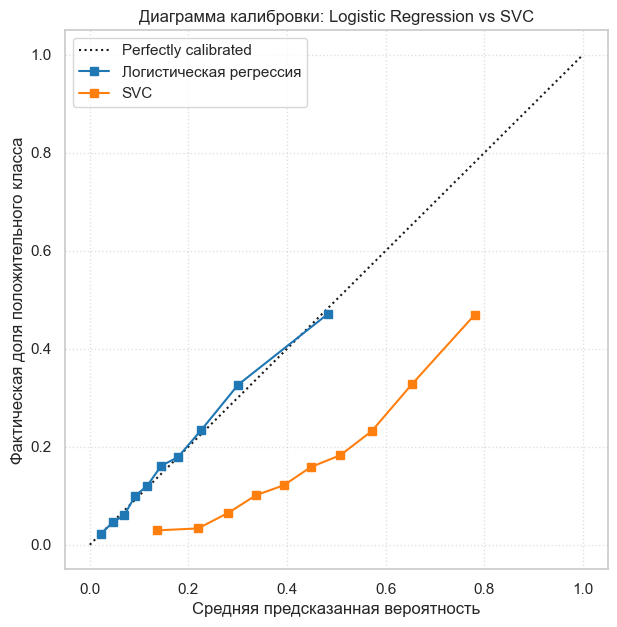

In [116]:
calibrated_graphics(logistic_final, svc_final, X_calib, y_calib, 'Логистическая регрессия', 'SVC')

Калибровочная кривая показывает, что Logistic Regression уже до дополнительной калибровки хорошо согласует предсказанные вероятности с фактической долей кликов: её линия почти совпадает с диагональю идеальной калибровки.

SVC до калибровки заметно хуже откалиброван. Его кривая проходит существенно ниже диагонали, то есть модель завышает вероятность клика: предсказанные значения CTR оказываются выше фактической частоты положительного класса.

Таким образом, основная проблема калибровки наблюдается именно у SVC. Следующий шаг — применить изотоническую калибровку к SVC на отдельной calibration set


In [104]:
calibrated_svc = CalibratedClassifierCV(
    estimator=FrozenEstimator(svc_final),
    method="isotonic"
)
calibrated_logistic = CalibratedClassifierCV(
    estimator=FrozenEstimator(logistic_final),
    method="isotonic"
)
calibrated_svc.fit(X_calib, y_calib)
calibrated_logistic.fit(X_calib, y_calib)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",FrozenEstimat...iblinear'))]))
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the c

In [107]:
def callibrated_metrics(model1, model2, name):
    if hasattr(model1, "predict_proba"):
        y_proba_before = model1.predict_proba(X_test)[:, 1]
    else:
        y_proba_before = expit(model1.decision_function(X_test))

    y_proba_after = model2.predict_proba(X_test)[:, 1]

    print(name)
    print("=" * 100)
    print("Brier до:", brier_score_loss(y_test, y_proba_before))
    print("Brier после:", brier_score_loss(y_test, y_proba_after))
    print("=" * 100)

    print("LogLoss до:", log_loss(y_test, y_proba_before))
    print("LogLoss после:", log_loss(y_test, y_proba_after))

    print("PR-AUC до:", average_precision_score(y_test, y_proba_before))
    print("PR-AUC после:", average_precision_score(y_test, y_proba_after))


In [108]:
callibrated_metrics(svc_final, calibrated_svc, 'svc')

svc
Brier до: 0.19990803699645646
Brier после: 0.12505858113474347
LogLoss до: 0.5845814375982636
LogLoss после: 0.4292468700072096
PR-AUC до: 0.402211981994297
PR-AUC после: 0.3805369820362861


In [109]:
callibrated_metrics(logistic_final, calibrated_logistic, 'logistic')

logistic
Brier до: 0.12401284291545256
Brier после: 0.12437447649719852
LogLoss до: 0.3997147871012201
LogLoss после: 0.4095117411673609
PR-AUC до: 0.40462803032181127
PR-AUC после: 0.38401126925418555


In [113]:
def calibrated_graphics_after(model1, model2, X_test, y_test, name1, name2):
    fig, ax = plt.subplots(figsize=(7, 7))

    ax.grid(True, linestyle=":", alpha=0.6)

    CalibrationDisplay.from_estimator(
        model1,
        X_test,
        y_test,
        n_bins=10,
        strategy="quantile",
        name=name1,
        ax=ax,
        color="tab:blue"
    )

    CalibrationDisplay.from_estimator(
        model2,
        X_test,
        y_test,
        n_bins=10,
        strategy="quantile",
        name=name2,
        ax=ax,
        color="tab:orange"
    )



    ax.set_title("Диаграмма калибровки после калибровки")
    ax.set_xlabel("Средняя предсказанная вероятность")
    ax.set_ylabel("Фактическая доля положительного класса")
    ax.legend(loc="upper left")

    plt.show()


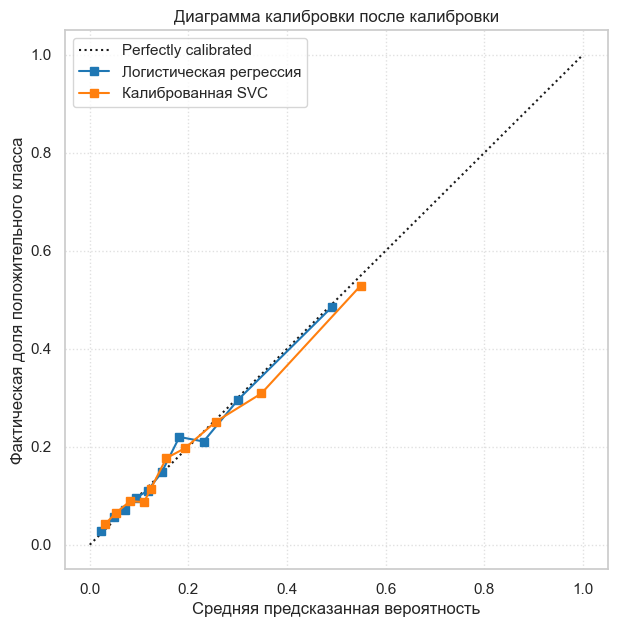

In [114]:
calibrated_graphics_after(logistic_final, calibrated_svc, X_test, y_test, "Логистическая регрессия","Калиброванная SVC")

После изотонической калибровки качество вероятностей SVC заметно улучшилось: Brier Score снизился с `0.1999` до `0.1251`, а Log Loss — с `0.5846` до `0.4292`.

При этом PR-AUC после калибровки снизился с `0.4022` до `0.3805`.

Для Logistic Regression изотоническая калибровка не дала улучшения: Brier Score, Log Loss и PR-AUC стали хуже. Поэтому логистическую регрессию лучше оставить без дополнительной калибровки, а для SVC использовать откалиброванную версию


In [117]:
def calibration_metrics(y_true, y_proba, n_bins=10):
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)

    bins = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.digitize(y_proba, bins) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)

    ece = 0
    mce = 0

    for bin_id in range(n_bins):
        mask = bin_ids == bin_id

        if not np.any(mask):
            continue

        bin_confidence = y_proba[mask].mean()
        bin_accuracy = y_true[mask].mean()
        bin_weight = mask.mean()

        gap = abs(bin_accuracy - bin_confidence)

        ece += bin_weight * gap
        mce = max(mce, gap)

    return {
        "brier": brier_score_loss(y_true, y_proba),
        "log_loss": log_loss(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
        "ece": ece,
        "mce": mce
    }

In [118]:
def compare_calibration(model_before, model_after, X_test, y_test, model_name):
    if hasattr(model_before, "predict_proba"):
        y_proba_before = model_before.predict_proba(X_test)[:, 1]
    else:
        y_proba_before = expit(model_before.decision_function(X_test))

    y_proba_after = model_after.predict_proba(X_test)[:, 1]

    results = {
        f"{model_name}_before": calibration_metrics(y_test, y_proba_before),
        f"{model_name}_after": calibration_metrics(y_test, y_proba_after)
    }

    return pd.DataFrame(results).T


In [119]:
svc_calibration_results = compare_calibration(
    svc_final,
    calibrated_svc,
    X_test,
    y_test,
    "svc"
)

display(svc_calibration_results.round(4))


,brier,log_loss,pr_auc,ece,mce
svc_before,0.1999,0.5846,0.4022,0.2633,0.3762
svc_after,0.1251,0.4292,0.3805,0.0094,0.7862


In [120]:
logistic_calibration_results = compare_calibration(
    logistic_final,
    calibrated_logistic,
    X_test,
    y_test,
    "logistic"
)

display(logistic_calibration_results.round(4))

,brier,log_loss,pr_auc,ece,mce
logistic_before,0.1240,0.3997,0.4046,0.0082,0.1603
logistic_after,0.1244,0.4095,0.3840,0.0100,0.3669


Изотоническая калибровка заметно улучшила вероятностное качество SVC: Brier Score снизился с `0.1999` до `0.1251`, Log Loss — с `0.5846` до `0.4292`, а ECE — с `0.2633` до `0.0094`. Это означает, что после калибровки предсказанные вероятности SVC стали намного ближе к фактическим частотам кликов.

При этом PR-AUC у SVC снизился с `0.4022` до `0.3805`, то есть качество ранжирования ухудшилось. MCE также вырос, что указывает на отдельные интервалы вероятностей с большим максимальным отклонением.

Для Logistic Regression дополнительная калибровка не дала улучшения: Brier Score, Log Loss, PR-AUC, ECE и MCE стали хуже. Поэтому Logistic Regression лучше оставить без калибровки


In [123]:
print('=' * 100)
print('Метрики основных моделей')
print('=' * 100)
display(pd.DataFrame(scores).T)

Метрики основных моделей


,pr_auc_mean,roc_auc_mean,f1_mean,recall_mean,precision_mean,pr_auc_std,best_params
dummy,0.172583,0.501577,0.172863,0.17104,0.174724,0.001516,NaN
logistic,0.404946,0.752276,0.228715,0.14314,0.569539,0.015312,NaN
grid_logistic,0.418896,0.759146,0.21634,0.13135,0.614822,0.014942,"{'model__C': 0.1, 'model__class_weight': None}"


In [124]:
final_models_summary = (
    pd.DataFrame(final_metrics)
    .T
    .sort_values(by="pr_auc", ascending=False)
)

display(final_models_summary.round(4))

,pr_auc,f1,recall,precision,brier,log_loss
logistic_final,0.4046,0.2058,0.1240,0.6038,0.1240,0.3997
svc_final,0.4022,0.4222,0.6597,0.3105,0.1999,0.5846


In [125]:
calibration_summary = pd.concat([
    svc_calibration_results,
    logistic_calibration_results
])

display(calibration_summary.round(4))

,brier,log_loss,pr_auc,ece,mce
svc_before,0.1999,0.5846,0.4022,0.2633,0.3762
svc_after,0.1251,0.4292,0.3805,0.0094,0.7862
logistic_before,0.1240,0.3997,0.4046,0.0082,0.1603
logistic_after,0.1244,0.4095,0.3840,0.0100,0.3669


In [126]:
top_5_features = coef_df.head(5)

display(top_5_features)

,feature,coef,abs_coef
53,target__device_id,6.880547,6.880547
54,target__device_model,3.806815,3.806815
52,target__app_id,2.756959,2.756959
57,target__C14,2.709335,2.709335
56,target__site_id,2.331846,2.331846


## Выводы

Качество моделей заметно улучшилось по сравнению с базовой моделью. DummyClassifier показал PR-AUC около `0.17`, тогда как Logistic Regression и SVC дали PR-AUC около `0.40`.

Лучшей финальной моделью по совокупности метрик стала Logistic Regression: она показала более высокий PR-AUC, лучший Log Loss и Brier Score по сравнению с SVC до калибровки. SVC лучше находит положительный класс и имеет более высокий recall, но делает больше ложноположительных предсказаний.

На вероятность клика сильнее всего влияют признаки, связанные с устройством, приложением и рекламной площадкой: `device_id`, `device_model`, `app_id`, `C14`, `site_id`, `site_domain`. По one-hot признакам заметное отрицательное влияние оказывают отдельные категории `app_category`, `site_category`, `C16`, `device_type` и `device_conn_type`.

Logistic Regression уже до дополнительной калибровки показала хорошее качество вероятностей: её калибровочная кривая близка к линии идеальной калибровки, а Brier Score составляет около `0.124`. Для SVC изотоническая калибровка заметно улучшила Brier Score, Log Loss и ECE, но снизила PR-AUC.

Модель можно считать готовой к базовому использованию: она заметно превосходит DummyClassifier, показывает стабильное качество по PR-AUC и даёт адекватные вероятностные оценки. Logistic Regression особенно хорошо подходит как финальная модель, так как сочетает хорошее качество ранжирования, низкие значения Log Loss и Brier Score, а также интерпретируемость коэффициентов.
## Рекомендации
Для улучшения модели стоит использовать `sklearn.preprocessing.TargetEncoder` с внутренней кросс-валидацией (`cv`), чтобы снизить риск переобучения при кодировании высококардинальных признаков и повысить качество модели потратив больше времени на обучение. (baseline модели на таком энкодере набрали 0.43 pr_auc против 0.4 на текущем)
Также имеет смысл поработать с feature инженерингом и более детально проработать модели с точки зрения необходимых признаков


## 12. Сохранение модели для продакшена

### 12.1 Сохраните артефакты

Сохраните:
1. пайплайн предобработки данных `preprocessor`;
2. финальную модель `calibrated_model`;
3. информацию о выбранных признаках.

### 12.2 Проверьте работоспособность вашего кода

- Загрузите сохранённые артефакты.
- Сделайте предсказания на новых данных.
- Убедитесь, что результаты совпадают.

In [133]:
joblib.dump(logistic_final, "logistic_final.joblib")
joblib.dump(X_train.columns.tolist(), "selected_features.joblib")
joblib.dump(logistic_final.named_steps["preprocessor"], "preprocessor.joblib")

['preprocessor.joblib']

In [135]:
loaded_model = joblib.load("logistic_final.joblib")
loaded_preprocessor = joblib.load("preprocessor.joblib")
loaded_features = joblib.load("selected_features.joblib")

X_check = X_test[loaded_features].head(5)

pred_before = logistic_final.predict_proba(X_check)[:, 1]
pred_after = loaded_model.predict_proba(X_check)[:, 1]

np.allclose(pred_before, pred_after)


True

In [136]:
pd.DataFrame({
    "prediction_ДОСОХРАНЕНИЯ": pred_before,
    "prediction_ПОСЛЕВЖВ": pred_after
})


,prediction_ДОСОХРАНЕНИЯ,prediction_ПОСЛЕВЖВ
0,0.160516,0.160516
1,0.343157,0.343157
2,0.389551,0.389551
3,0.067557,0.067557
4,0.103555,0.103555
